# 1&nbsp; Initialisation

## Imports

In [ ]:
# Python standard library packages to do file/folder manipulations,
# pickle is a package to store python variables
import glob, os, pickle, time, h5py, sys, re
sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCThermalPlots/RHCImaging')
sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCThermalPlots')
sys.path.append('Metabolism/VisualActivity/RHCVisualisation')
sys.path.append('Metabolism/VisualActivity')
sys.path.append('Metabolism')


# this packages helps load and save .mat files older than v7
import hdf5storage

# numpy works with arrays, pandas used to work with fancy numpy arrays
import numpy as np
import pandas as pd
from IPython.display import Image
# matplotlib is used to plot and animate to make movies
import matplotlib.pyplot as plt

# Scikit-learn is a go-to library in Python for all things related to machine learning
from sklearn.decomposition import PCA
from Metabolism.libco2 import getExpDTs, MetabolicExp

from utils import plot_ethogram, download_dataset
%matplotlib inline

from dask.distributed import Client
# Start a client using all CPUs of this machine
client = Client()
client

distributed.diskutils - INFO - Found stale lock file and directory '/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/dask-worker-space/worker-p7b_nw78', purging
distributed.diskutils - INFO - Found stale lock file and directory '/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/dask-worker-space/worker-t_xd1yzc', purging
distributed.diskutils - INFO - Found stale lock file and directory '/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/dask-worker-space/worker-7r7600sl', purging
distributed.diskutils - INFO - Found stale lock file and directory '/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/dask-worker-space/worker-14rlo67q', purging


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:58050,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 12
Started: Just now,Total memory: 32.00 GiB
Comm: tcp://127.0.0.1:58074,Total threads: 3
Dashboard: http://127.0.0.1:58076/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:58055,


## Configuration

In [2]:
resolution = 600 # in seconds --> 10 minutes
WideNormalisation = True # Whether to normalise all data across datasets (True) or normalise each dataset independently (False)
projectPath = r"/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivity/"
save_files = True
force_reload = False # Whether to force reloading of the data or use the intermediate .pkl files if they exist
exps_list_imgs_loaded = ['SharpDay', 'SharpNight', 'SoftDay', 'SoftNight', 'Constant']
all_exps_list = ['SharpDay', 'SharpNight', 'SoftDay', 'SoftNight', 'Idle', 'Constant', 'Observation']
used_exp_list = all_exps_list # Select the experiments to use for ethogram generation

## Dataset(s) loading

In [3]:
# Build set of required keys (exp, hive_nb, ihl) from used_exp_list, which the user sets
# to either all_exps_list or exps_list_imgs_loaded (see the config cell) to control whether
# Idle/Observation are included alongside the Sharp/Soft/Constant experiments.
intermediate_dir = "Results/Intermediate_Results"

required_keys = set()
for exp in used_exp_list:
    exps_ihls_entry = MetabolicExp.exps_ihls.get(exp)
    hives_used = [int(h[-1]) for h in exps_ihls_entry.keys() if exps_ihls_entry.get(h)]
    for hive_nb in hives_used:
        ihls = exps_ihls_entry.get(f'hive{hive_nb}', [])
        for _ihl in ihls:
            if _ihl is None:
                continue
            required_keys.add((exp, hive_nb, _ihl))

exps_dfs = {}
missing_keys = set(required_keys)

if not force_reload:
    # Load whichever required datasets already have their own pickle file
    # (Results/Intermediate_Results/{exp}_hive{hive_nb}_{ihl}.pkl); anything left in
    # missing_keys after this gets downloaded below, so a partial cache is fine.
    for key in sorted(required_keys):
        exp, hive_nb, ihl = key
        source_id = f"{exp}_hive{hive_nb}_{ihl}"
        pkl_path = os.path.join(intermediate_dir, f"{source_id}.pkl")
        if os.path.exists(pkl_path):
            with open(pkl_path, 'rb') as f:
                exps_dfs[key] = pickle.load(f)
            missing_keys.discard(key)
            print(f"Loaded {source_id} from pickle {exps_dfs[key].shape}.")
else:
    print("force_reload is True: skipping the pickle cache, downloading all datasets.")

if missing_keys:
    print(f"Downloading {len(missing_keys)} missing dataset(s): {sorted(missing_keys)}")
    for exp, hive_nb, _ihl in sorted(missing_keys):
        bucket = MetabolicExp.buckets_by_type[exp]
        start_ts, end_ts = getExpDTs(exp, hive_nb)
        imgs_path = MetabolicExp.imgs_paths_by_type[exp]
        print(f"Downloading dataset for experiment: {exp}, hive: {hive_nb}, IHL: {_ihl}")
        df_exp = download_dataset(hive_nb=hive_nb, ihl=_ihl,
                                resolution=resolution,
                                start_ts=start_ts,
                                end_ts=end_ts,
                                only_amb_T=True,
                                visualActivityPath=imgs_path,
                                bucket=bucket)
        print(f"Data shape: {df_exp.shape}")
        print(df_exp.head())
        exps_dfs[(exp, hive_nb, _ihl)] = df_exp
else:
    print("All required datasets were loaded from their pickle files.")


Loaded Constant_hive2_upper from pickle (419, 5).
Loaded Idle_hive1_upper from pickle (1475, 5).
Loaded Idle_hive2_upper from pickle (1351, 5).
Loaded Observation_hive1_lower from pickle (7227, 5).
Loaded Observation_hive1_upper from pickle (7232, 5).
Loaded Observation_hive2_lower from pickle (3491, 5).
Loaded Observation_hive2_upper from pickle (3391, 5).
Loaded SharpDay_hive1_upper from pickle (1526, 5).
Loaded SharpDay_hive2_upper from pickle (1233, 5).
Loaded SharpNight_hive1_upper from pickle (1988, 5).
Loaded SharpNight_hive2_upper from pickle (981, 5).
Loaded SoftDay_hive1_upper from pickle (1871, 5).
Loaded SoftDay_hive2_upper from pickle (1433, 5).
Loaded SoftNight_hive1_upper from pickle (2193, 5).
All required datasets were loaded from their pickle files.


In [4]:
if save_files:
    # Store each dataset as its own pickle file (Results/Intermediate_Results/{exp}_hive{hive_nb}_{ihl}.pkl)
    # instead of one combined exps_dfs.pkl, so a future run with force_reload=False can reload
    # whichever datasets are already cached and only re-download the rest (see the loading cell
    # above). Each file is overwritten in place -- that's the point of a cache, unlike the old
    # incremental-suffix behavior which just accumulated stale numbered copies.
    intermediate_dir = "Results/Intermediate_Results"
    os.makedirs(intermediate_dir, exist_ok=True)
    for (exp, hive_nb, _ihl), df_exp in exps_dfs.items():
        source_id = f"{exp}_hive{hive_nb}_{_ihl}"
        pkl_path = os.path.join(intermediate_dir, f"{source_id}.pkl")
        with open(pkl_path, 'wb') as f:
            pickle.dump(df_exp, f)
    print(f"Saved {len(exps_dfs)} dataset(s) to {intermediate_dir}/")


Saved 14 dataset(s) to Results/Intermediate_Results/


In [5]:
# full_dts stores the full data range for all datasets
full_dts = {}
for key, df in exps_dfs.items():
    full_dts[key] = pd.date_range(df.index.min(), df.index.max(), freq='10min')
print("Full data ranges for all datasets:")
for key, dts in full_dts.items():
    print(f"Dataset {key}: {dts.min()} to {dts.max()}")

Full data ranges for all datasets:
Dataset ('Constant', 2, 'upper'): 2024-11-19 18:20:00+00:00 to 2024-11-22 16:00:00+00:00
Dataset ('Idle', 1, 'upper'): 2024-11-12 06:00:00+00:00 to 2024-11-22 16:00:00+00:00
Dataset ('Idle', 2, 'upper'): 2024-11-09 23:00:00+00:00 to 2024-11-19 08:00:00+00:00
Dataset ('Observation', 1, 'lower'): 2024-09-04 16:00:00+00:00 to 2024-10-28 08:40:00+00:00
Dataset ('Observation', 1, 'upper'): 2024-09-04 16:00:00+00:00 to 2024-10-28 08:40:00+00:00
Dataset ('Observation', 2, 'lower'): 2024-10-02 19:00:00+00:00 to 2024-10-28 08:40:00+00:00
Dataset ('Observation', 2, 'upper'): 2024-10-03 17:00:00+00:00 to 2024-10-28 08:40:00+00:00
Dataset ('SharpDay', 1, 'upper'): 2024-12-06 15:40:00+00:00 to 2024-12-17 10:20:00+00:00
Dataset ('SharpDay', 2, 'upper'): 2024-11-27 22:00:00+00:00 to 2024-12-06 15:40:00+00:00
Dataset ('SharpNight', 1, 'upper'): 2024-11-22 16:10:00+00:00 to 2024-12-06 15:40:00+00:00
Dataset ('SharpNight', 2, 'upper'): 2024-12-06 15:40:00+00:00 to 2024

In [6]:
exps_dfs_interpolated = exps_dfs.copy()
# First linearly interpolate any NaN values that may exist in the dataframes over 5 rows, beyond that leave them as NaN
for key, df in exps_dfs_interpolated.items():
    len_before = len(df)
    df = df.astype(float)
    nans_before = int(df.isna().sum().sum())
    df.interpolate(method='time', limit=6, limit_direction='both', inplace=True)
    nans_after = int(df.isna().sum().sum())
    exps_dfs_interpolated[key] = df
    print(f"Interpolated {nans_before - nans_after} NaN cells for dataset {key}. Remaining NaN cells: {nans_after}. Remaining lines: {len(df)}")

# Drop any NaN values that may still exist after resampling
exps_dfs_dropna = exps_dfs_interpolated.copy()
for key, df in exps_dfs_dropna.items():
    len_before = len(df)
    rows_with_nan_before = int(df.isna().any(axis=1).sum())
    df = df.dropna(how='any')
    exps_dfs_dropna[key] = df
    print(f"Dropped {len_before - len(df)} rows with NaN values for dataset {key}. Rows with NaN before drop: {rows_with_nan_before}. Remaining lines: {len(df)}")

Interpolated 0 NaN cells for dataset ('Constant', 2, 'upper'). Remaining NaN cells: 0. Remaining lines: 419
Interpolated 16 NaN cells for dataset ('Idle', 1, 'upper'). Remaining NaN cells: 0. Remaining lines: 1475
Interpolated 3 NaN cells for dataset ('Idle', 2, 'upper'). Remaining NaN cells: 0. Remaining lines: 1351
Interpolated 151 NaN cells for dataset ('Observation', 1, 'lower'). Remaining NaN cells: 4175. Remaining lines: 7227
Interpolated 130 NaN cells for dataset ('Observation', 1, 'upper'). Remaining NaN cells: 2994. Remaining lines: 7232
Interpolated 60 NaN cells for dataset ('Observation', 2, 'lower'). Remaining NaN cells: 1488. Remaining lines: 3491
Interpolated 48 NaN cells for dataset ('Observation', 2, 'upper'). Remaining NaN cells: 1388. Remaining lines: 3391
Interpolated 6 NaN cells for dataset ('SharpDay', 1, 'upper'). Remaining NaN cells: 0. Remaining lines: 1526
Interpolated 1 NaN cells for dataset ('SharpDay', 2, 'upper'). Remaining NaN cells: 0. Remaining lines: 12

Raw Data Plots

In [7]:
df_plots = exps_dfs_dropna['SharpDay', 1, 'upper'].copy()

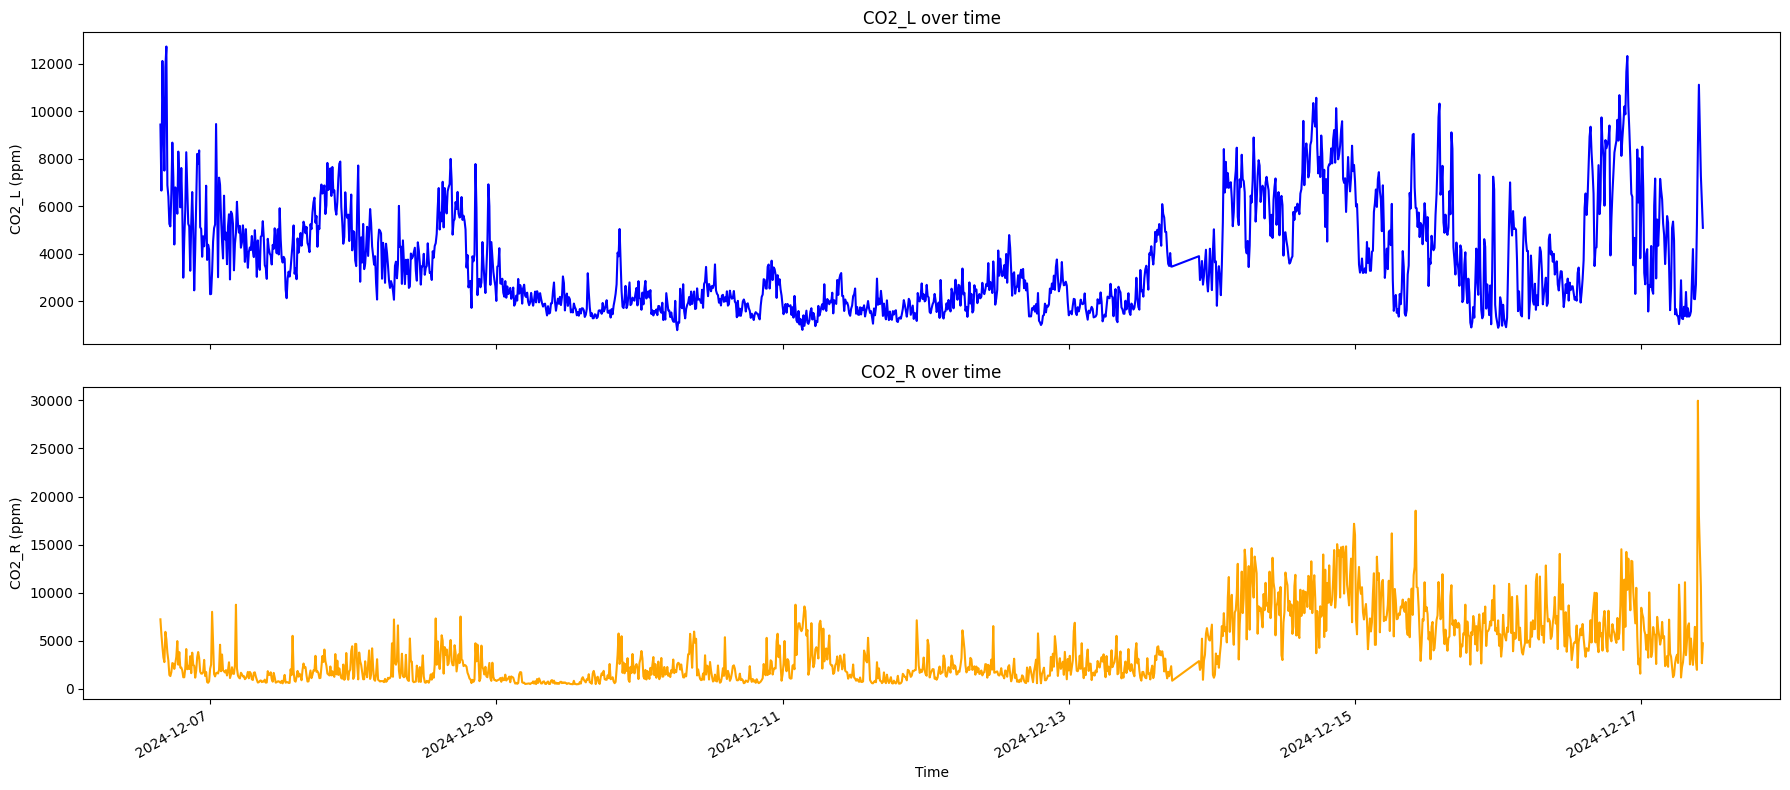

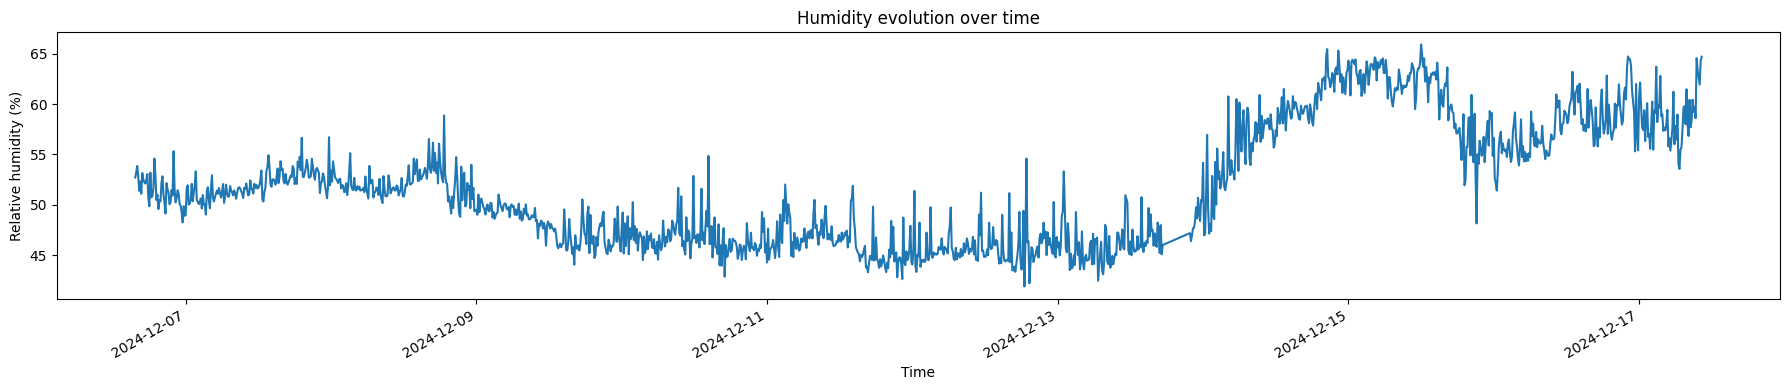

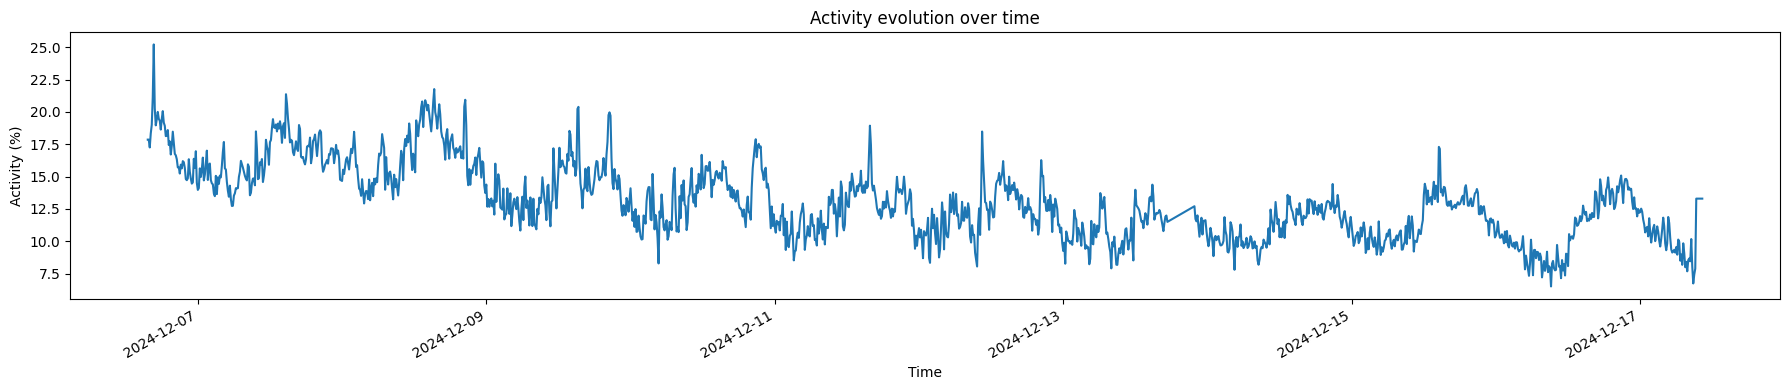

In [8]:
# --- Columns ---
temp_cols = [f"t{str(i).zfill(2)}" for i in range(64)]  # t00..t63
co2_col = ["co2_L", "co2_R"]
humid_col = "rel_humid"

# =========================
# 1) Boxplots for temperature sensors (t00..t63)
# =========================
if temp_cols[0] in df_plots.columns:
    print("Temperature columns found. Proceeding with boxplot.")
    ax = df_plots[temp_cols].boxplot(figsize=(18, 5), rot=90,showfliers=False)
    ax.set_xlabel("Temperature sensor")
    ax.set_ylabel("Temperature (°C)")
    ax.set_title("Temperature sensors distribution (t00–t63)")
    plt.tight_layout()
    plt.show()

# =========================
# 2) CO2 over time (separate figure)
# =========================
# Make a two-row plot for CO2_L and CO2_R, sharig the same x-axis
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(18, 8), sharex=True)
df_plots[co2_col[0]].plot(ax=axs[0], color='blue', title='CO2_L over time')
axs[0].set_ylabel("CO2_L (ppm)")
df_plots[co2_col[1]].plot(ax=axs[1], color='orange', title='CO2_R over time')
axs[1].set_xlabel("Time")
axs[1].set_ylabel("CO2_R (ppm)")
plt.tight_layout()
plt.show()

# =========================
# 3) Humidity over time (separate figure)
# =========================
ax = df_plots[humid_col].plot(figsize=(18, 4))
ax.set_xlabel("Time")
ax.set_ylabel("Relative humidity (%)")
ax.set_title("Humidity evolution over time")
plt.tight_layout()
plt.show()


# =========================
# 4) Activity over time (separate figure)
# =========================
activity_plot = df_plots.loc[:, 'activity']*100
ax = activity_plot.plot(figsize=(18, 4))
ax.set_xlabel("Time")
ax.set_ylabel("Activity (%)")
ax.set_title("Activity evolution over time")
plt.tight_layout()
plt.show()

## Data availability checking

Total datapoints across all datasets: 27166
Datapoints taken into account (>=30h): 24806
Percentage of datapoints taken into account: 91.31%

Dataset ('Constant', 2, 'upper'):
Total datapoints: 419
Datapoints taken into account (>=30h): 419
Percentage of datapoints taken into account: 100.00%

First timestamp: 2024-11-19 18:20:00+00:00
Last timestamp: 2024-11-22 16:00:00+00:00

Dataset ('Idle', 1, 'upper'):
Total datapoints: 1475
Datapoints taken into account (>=30h): 1475
Percentage of datapoints taken into account: 100.00%

First timestamp: 2024-11-12 06:00:00+00:00
Last timestamp: 2024-11-22 16:00:00+00:00

Dataset ('Idle', 2, 'upper'):
Total datapoints: 1351
Datapoints taken into account (>=30h): 1351
Percentage of datapoints taken into account: 100.00%

First timestamp: 2024-11-09 23:00:00+00:00
Last timestamp: 2024-11-19 08:00:00+00:00

Dataset ('Observation', 1, 'lower'):
Total datapoints: 4207
Datapoints taken into account (>=30h): 3262
Percentage of datapoints taken into accou

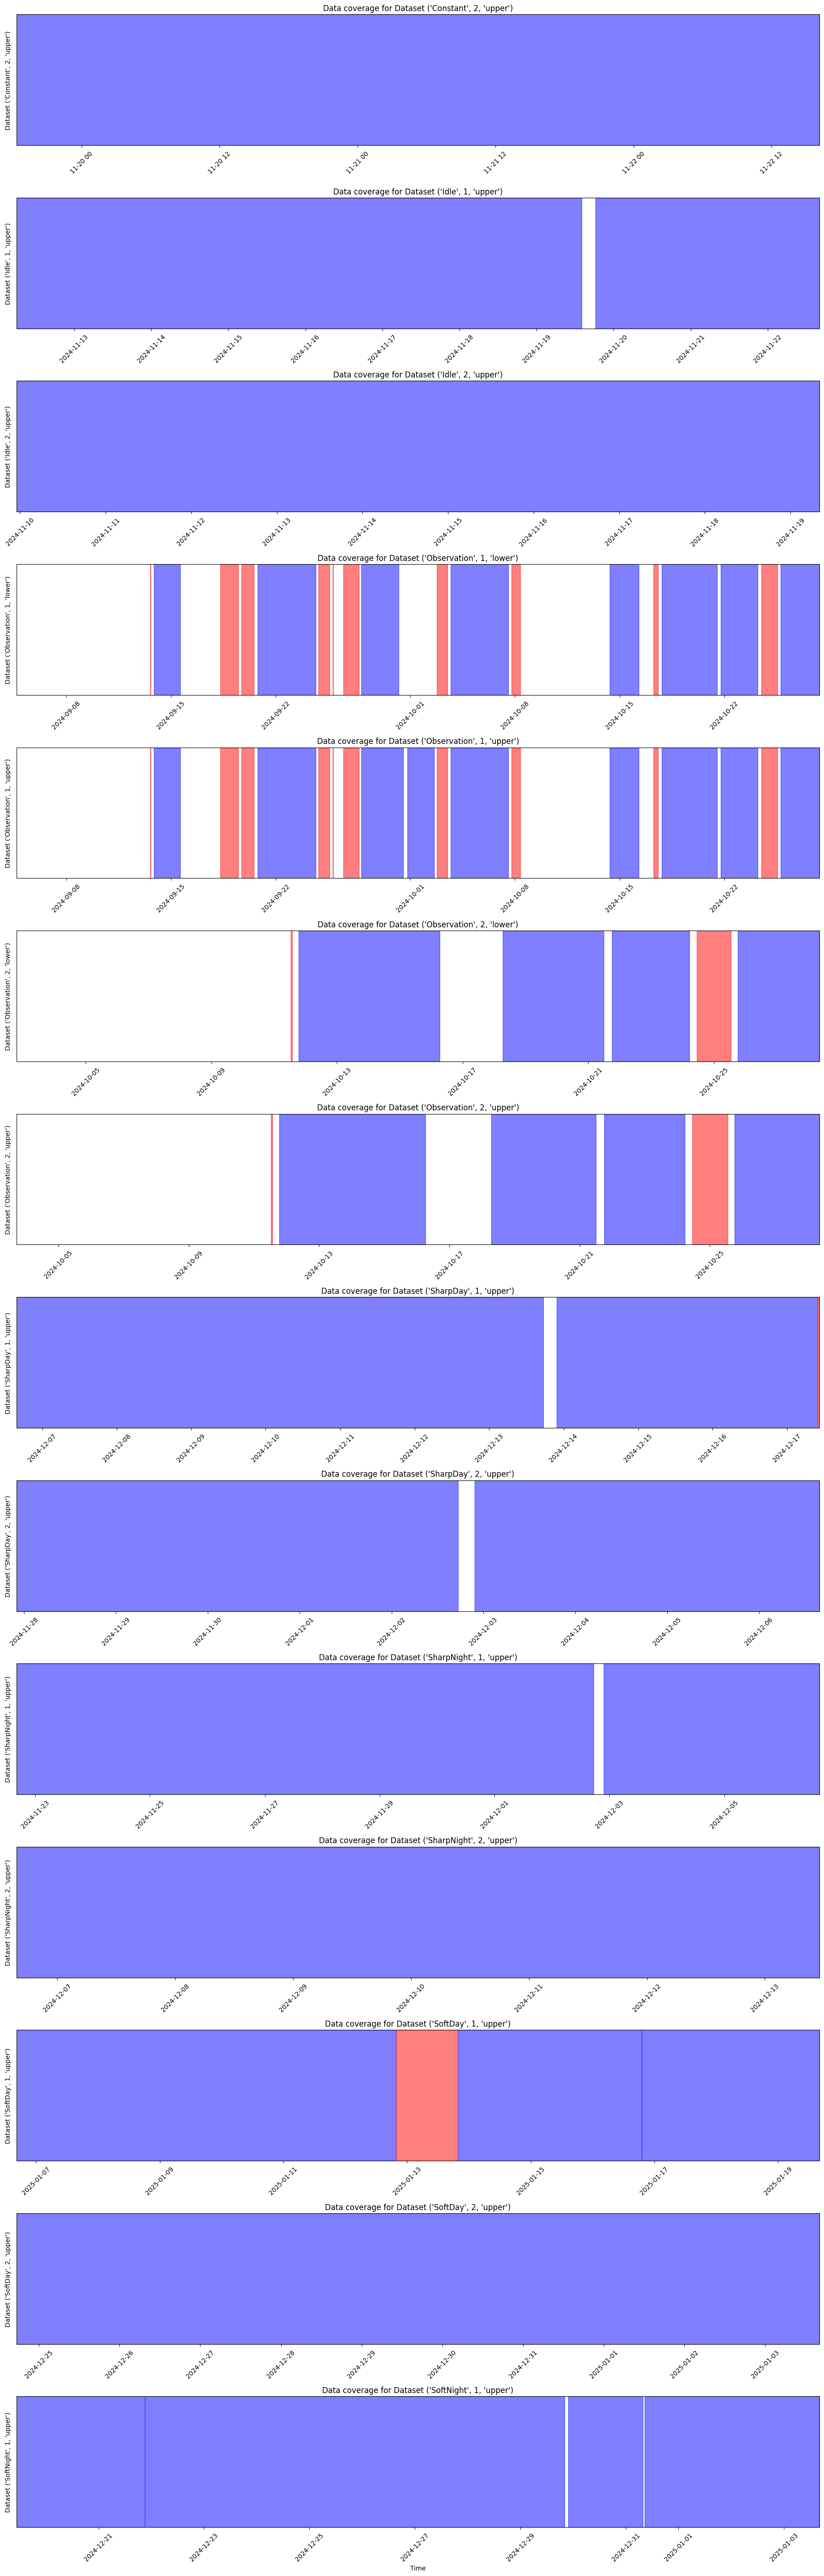

In [9]:
# Use full_dts as x-axis; color contiguous data chunks blue if >=30h, else red.

step = pd.Timedelta(seconds=resolution)
threshold = pd.Timedelta(hours=30)

n_rows = len(exps_dfs_dropna)
fig_height = 4 * n_rows  # Adjust height based on number of datasets
fig, axs = plt.subplots(nrows=n_rows, ncols=1, figsize=(18, fig_height), sharex=False)

for i,(key, df) in enumerate(exps_dfs_dropna.items()):
    full_dt = pd.DatetimeIndex(full_dts[key])
    mask = full_dt.isin(df.index)

    # find contiguous True runs in mask
    runs = []
    in_run = False
    for idx, val in enumerate(mask):
        if val and not in_run:
            run_start = idx
            in_run = True
        elif not val and in_run:
            run_end = idx - 1
            runs.append((run_start, run_end))
            in_run = False
    if in_run:
        runs.append((run_start, len(mask) - 1))

    # draw spans on the full_dts axis
    for start, end in runs:
        duration = (end - start + 1) * step
        color = 'blue' if duration >= threshold else 'red'
        start_dt = full_dt[start].to_pydatetime()
        end_dt = (full_dt[end] + step).to_pydatetime()
        axs[i].axvspan(start_dt, end_dt, color=color, alpha=0.5)

    axs[i].set_ylabel(f"Dataset {key}")
    axs[i].set_ylim(0, 1)
    axs[i].set_yticks([])
    axs[i].set_title(f"Data coverage for Dataset {key}")
    axs[i].set_xlim(full_dt[0].to_pydatetime(), (full_dt[-1] + step).to_pydatetime())
    axs[i].tick_params(axis='x', rotation=45)

axs[-1].set_xlabel("Time")
plt.tight_layout()

# Print how much datapoints exist in total over all 3 datasets (blue + red) and what percentage are taken into account (blue/(blue + red))
total_points = sum(len(df) for df in exps_dfs_dropna.values())
# Count blue points (>=30h) and red points (<30h)
blue_points = 0
for key, df in exps_dfs_dropna.items():
    full_dt = pd.DatetimeIndex(full_dts[key])
    mask = full_dt.isin(df.index)

    # find contiguous True runs in mask
    runs = []
    in_run = False
    for idx, val in enumerate(mask):
        if val and not in_run:
            run_start = idx
            in_run = True
        elif not val and in_run:
            run_end = idx - 1
            runs.append((run_start, run_end))
            in_run = False
    if in_run:
        runs.append((run_start, len(mask) - 1))

    # count blue points (>=30h)
    for start, end in runs:
        duration = (end - start + 1) * step
        if duration >= threshold:
            blue_points += (end - start + 1)

print(f"Total datapoints across all datasets: {total_points}")
print(f"Datapoints taken into account (>=30h): {blue_points}")
print(f"Percentage of datapoints taken into account: {blue_points / total_points * 100:.2f}%\n")

# Same as above but per dataset
for key, df in exps_dfs_dropna.items():
    full_dt = pd.DatetimeIndex(full_dts[key])
    mask = full_dt.isin(df.index)

    # find contiguous True runs in mask
    runs = []
    in_run = False
    for idx, val in enumerate(mask):
        if val and not in_run:
            run_start = idx
            in_run = True
        elif not val and in_run:
            run_end = idx - 1
            runs.append((run_start, run_end))
            in_run = False
    if in_run:
        runs.append((run_start, len(mask) - 1))

    # count blue points (>=30h)
    blue_points_dataset = 0
    for start, end in runs:
        duration = (end - start + 1) * step
        if duration >= threshold:
            blue_points_dataset += (end - start + 1)

    print(f"Dataset {key}:")
    print(f"Total datapoints: {len(df)}")
    print(f"Datapoints taken into account (>=30h): {blue_points_dataset}")
    print(f"Percentage of datapoints taken into account: {blue_points_dataset / len(df) * 100:.2f}%\n")
    # Print first and last dt of the dataset
    print(f"First timestamp: {df.index.min()}")
    print(f"Last timestamp: {df.index.max()}\n")


# 2&nbsp; Preprocessing of Data

First we shift the timestamps to separate datasets temporaly

In [10]:
df_shifted = []

for i, (key, df) in enumerate(exps_dfs_dropna.items()):

    df = df.copy()

    # Save the real timestamp
    df["real_timestamp"] = df.index

    # Add a source id column
    df["source_id"] = f"{key[0]}_hive{key[1]}_{key[2]}"

    df_shifted.append(df)

# Concatenate into one DataFrame
df_concat = pd.concat(df_shifted, axis=0)
df_concat = df_concat.sort_index()

print(df_concat.index[:10])
print(len(df_concat))
dataset_names = df_concat["source_id"].unique()
print(dataset_names)

DatetimeIndex(['2024-09-13 14:30:00+00:00', '2024-09-13 14:30:00+00:00', '2024-09-13 14:40:00+00:00', '2024-09-13 14:40:00+00:00', '2024-09-13 14:50:00+00:00', '2024-09-13 14:50:00+00:00', '2024-09-13 15:00:00+00:00', '2024-09-13 15:00:00+00:00', '2024-09-13 15:10:00+00:00', '2024-09-13 15:10:00+00:00'], dtype='datetime64[ns, tzutc()]', name='datetime', freq=None)
27166
['Observation_hive1_upper' 'Observation_hive1_lower'
 'Observation_hive2_upper' 'Observation_hive2_lower' 'Idle_hive2_upper'
 'Idle_hive1_upper' 'Constant_hive2_upper' 'SharpNight_hive1_upper'
 'SharpDay_hive2_upper' 'SharpDay_hive1_upper' 'SharpNight_hive2_upper'
 'SoftNight_hive1_upper' 'SoftDay_hive2_upper' 'SoftDay_hive1_upper']


## Scaling

In [11]:
if WideNormalisation:
    df_scaled = df_concat.copy()
    # We normalise all datasets together
    # Temperature columns
    temp_cols = [f"t{i:02d}" for i in range(64)]
    if not all(col in df_scaled.columns for col in temp_cols):
        print("Warning: Not all temperature columns found in the DataFrame. Skipping temperature normalization.")
    if all(col in df_scaled.columns for col in temp_cols):
        temp_mean = df_scaled[temp_cols].values.mean()
        print("Temperature mean:", temp_mean)
        temp_std = df_scaled[temp_cols].values.std()
        print("Temperature std:", temp_std)

        df_scaled[temp_cols] = (df_scaled[temp_cols] - temp_mean) / temp_std

    # CO2 columns
    co2_cols = ["co2_L", "co2_R"]
    co2_mean = df_scaled[co2_cols].values.mean()
    co2_std = df_scaled[co2_cols].values.std()

    df_scaled[co2_cols] = (df_scaled[co2_cols] - co2_mean) / co2_std

    # Humidity column
    humid_col = "rel_humid"
    humid_mean = df_scaled[humid_col].mean()
    humid_std = df_scaled[humid_col].std()
    df_scaled[humid_col] = (df_scaled[humid_col] - humid_mean) / humid_std

    # Activity column
    activity_col = "activity"
    if activity_col in df_scaled.columns:
        activity_mean = df_scaled[activity_col].mean()
        activity_std = df_scaled[activity_col].std()
        df_scaled[activity_col] = (df_scaled[activity_col] - activity_mean) / activity_std

    # Tamb column
    tamb_col = "Tamb"
    if tamb_col in df_scaled.columns:
        tamb_mean = df_scaled[tamb_col].mean()
        tamb_std = df_scaled[tamb_col].std()
        df_scaled[tamb_col] = (df_scaled[tamb_col] - tamb_mean) / tamb_std

else:
    dfs_scaled = []
    for dataset_id in df_concat["source_id"].unique():
        dataset_df = df_concat[df_concat["source_id"] == dataset_id]
        from sklearn.preprocessing import StandardScaler

        # We only keep numerical columns for scaling
        X = dataset_df.select_dtypes(include='number')

        # Normalization
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Create a normalized DataFrame and keep the timestamp metadata alongside it
        X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=dataset_df.index)
        meta_cols = dataset_df[['real_timestamp', 'source_id']].copy()
        dfs_scaled.append(pd.concat([X_scaled, meta_cols], axis=1))

    df_scaled = pd.concat(dfs_scaled, axis=0)

print("Scaled DataFrame head:")
print(df_scaled.head())

Scaled DataFrame head:
                             Tamb      co2_L     co2_R   rel_humid  activity       real_timestamp             source_id        
datetime                                                                                                                       
2024-09-13 14:30:00+00:00  0.819281  0.496401  0.946240  0.677123   0.798733 2024-09-13 14:30:00+00:00  Observation_hive1_upper
2024-09-13 14:30:00+00:00  0.599700  0.839510  0.089856  0.910912  -0.147689 2024-09-13 14:30:00+00:00  Observation_hive1_lower
2024-09-13 14:40:00+00:00  0.820209  1.132611  0.946240  0.667560   1.106064 2024-09-13 14:40:00+00:00  Observation_hive1_upper
2024-09-13 14:40:00+00:00  0.686975  1.308796  0.089856  0.811680   0.321289 2024-09-13 14:40:00+00:00  Observation_hive1_lower
2024-09-13 14:50:00+00:00  0.712044  2.791898  0.089856  0.893135   0.541732 2024-09-13 14:50:00+00:00  Observation_hive1_lower


In [12]:
df_merged = df_scaled.drop(columns=['source_id', 'real_timestamp']).copy()
print(df_merged.columns)

Index(['Tamb', 'co2_L', 'co2_R', 'rel_humid', 'activity'], dtype='object')


## PCA
Compute PCA on the concatenated dataset

In [13]:
#Parameter for PCA
variance_threshold = 0.99

We'll pick the first 4 components that explain 99.0% of the variance.


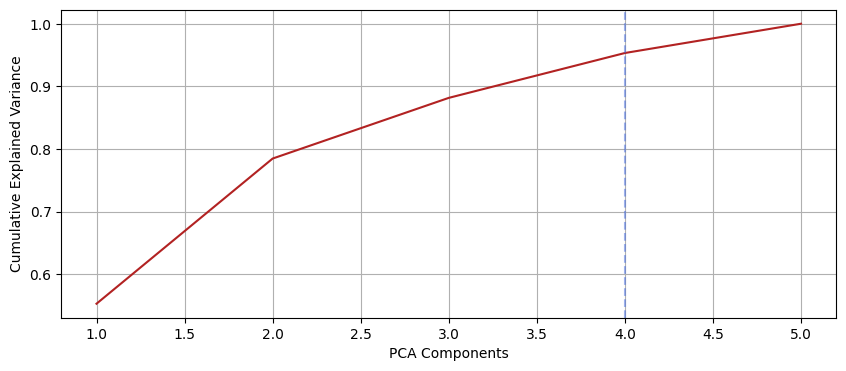

In [14]:
x = df_merged

#We are using sklearn.decomposition.PCA here
p = PCA()
y = p.fit_transform(x)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(np.arange(1, x.shape[1]+1), np.cumsum(p.explained_variance_ratio_), color='firebrick')

#This calculates the number of PCA components required to surpass the variance threshold
comps_above_thresh = np.argwhere(np.cumsum(p.explained_variance_ratio_)>variance_threshold)[0][0]

ax.axvline(x=comps_above_thresh, color='royalblue', linestyle='--', alpha=0.5)
#ax.text(x = comps_above_thresh + 1, y = 0.5, s=f'{comps_above_thresh}th component')
ax.set_xlabel('PCA Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.grid()

print(f'We\'ll pick the first {comps_above_thresh} components that explain {variance_threshold*100}% of the variance.')

PCA Components Visualization

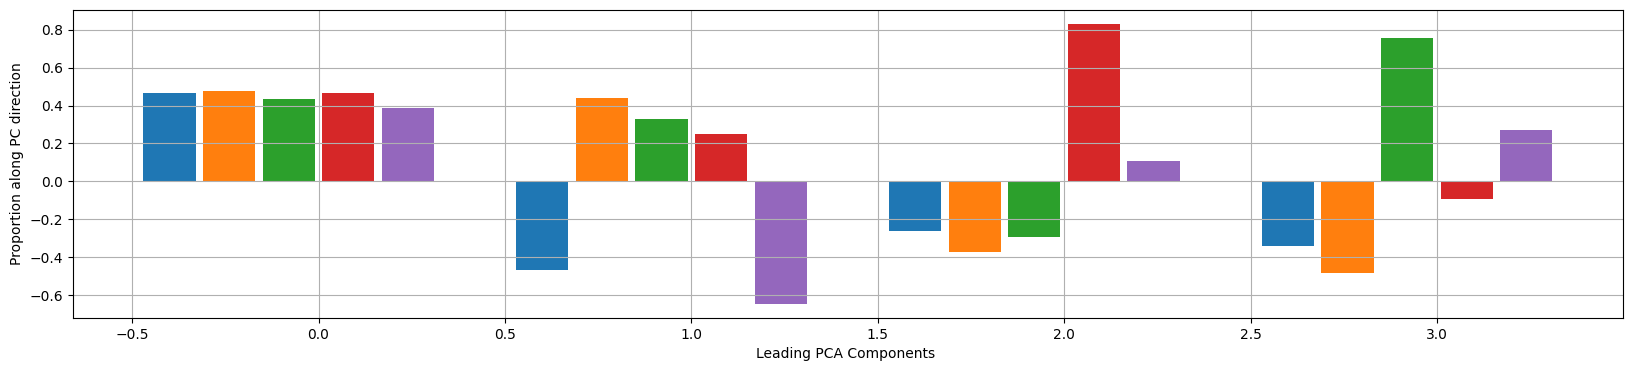

In [15]:
fig, ax = plt.subplots(figsize=(20,4))

for i in range(comps_above_thresh):
  for pi in range(x.shape[1]):
    ax.bar((i-0.4+pi*(0.8/x.shape[1])), p.components_[i, pi], width=(0.7/x.shape[1]), label=f'Angle{i}')
  ax.set_prop_cycle(None)

ax.set_xlabel('Leading PCA Components ')
ax.set_ylabel('Proportion along PC direction')
# ax.legend()
ax.grid()
plt.show()

Picking PCA Components

In [16]:
#picking PCA components above threshold
y = y[:,:comps_above_thresh]
print(y.shape)

# Re-divide the PCA embeddings into the original datasets based on the source_id column
df_concat['pca_embedding'] = list(y)
pca_embeddings = []
for dataset_id in dataset_names:
    dataset_df = df_concat[df_concat["source_id"] == dataset_id].loc[:, ['pca_embedding', 'real_timestamp']].copy()
    pca_embeddings.append(dataset_df)
    print(f"Dataset {dataset_id}: dataframe with shape {dataset_df.shape}")

print(f"Example of PCA embedding for dataset 1:\n{pca_embeddings[1].head()}\n")

(27166, 4)
Dataset Observation_hive1_upper: dataframe with shape (4505, 2)
Dataset Observation_hive1_lower: dataframe with shape (4207, 2)
Dataset Observation_hive2_upper: dataframe with shape (2003, 2)
Dataset Observation_hive2_lower: dataframe with shape (2003, 2)
Dataset Idle_hive2_upper: dataframe with shape (1351, 2)
Dataset Idle_hive1_upper: dataframe with shape (1475, 2)
Dataset Constant_hive2_upper: dataframe with shape (419, 2)
Dataset SharpNight_hive1_upper: dataframe with shape (1988, 2)
Dataset SharpDay_hive2_upper: dataframe with shape (1233, 2)
Dataset SharpDay_hive1_upper: dataframe with shape (1526, 2)
Dataset SharpNight_hive2_upper: dataframe with shape (981, 2)
Dataset SoftNight_hive1_upper: dataframe with shape (2174, 2)
Dataset SoftDay_hive2_upper: dataframe with shape (1433, 2)
Dataset SoftDay_hive1_upper: dataframe with shape (1868, 2)
Example of PCA embedding for dataset 1:
                                            pca_embedding                          real_ti

# 3.&nbsp; Creating an mmpy project directory

Setup Folders

In [17]:
import sys
sys.path.insert(0, os.path.abspath('motionmapperpy-master'))
for module_name in list(sys.modules):
    if module_name == 'motionmapperpy' or module_name.startswith('motionmapperpy.'):
        del sys.modules[module_name]
import motionmapperpy as mmpy
print('Using motionmapperpy from:', mmpy.__file__)
%matplotlib inline

# This creates a project directory structure which will be used to store all motionmappery pipeline
# related data in one place.

mmpy.createProjectDirectory(projectPath)
for dataset_id, dataset_df in enumerate(pca_embeddings):
    # Save the PCA embeddings for each dataset into a .mat file
    dataset_name = dataset_names[dataset_id]
    dataset_real_timestamps = pd.to_datetime(dataset_df.loc[:, 'real_timestamp'], utc=True).view('int64').to_numpy()
    dataset_shifted_timestamps = pd.to_datetime(dataset_df.index, utc=True).view('int64')
    dataset_pca_embeddings = dataset_df.loc[:, 'pca_embedding']
    # Convert the array elements to np arrays too
    dataset_pca_embeddings = np.array([np.array(row) for row in dataset_pca_embeddings])
    dataset_projection_metadata = {
        'projections': dataset_pca_embeddings,
        'real_timestamps': dataset_real_timestamps,
        'shifted_timestamps': dataset_shifted_timestamps,
    }
    print(f"Saving {len(dataset_pca_embeddings)} points for dataset {dataset_name} to {projectPath}/Projections/{dataset_name}_pcaModes.mat")

    hdf5storage.savemat(f'{projectPath}/Projections/{dataset_name}_pcaModes.mat', dataset_projection_metadata)

Using motionmapperpy from: /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/motionmapperpy-master/motionmapperpy/__init__.py
Skipping, path already exists : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivity/
Skipping, path already exists : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivity//Projections
Skipping, path already exists : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivity//TSNE_Projections
Skipping, path already exists : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivity//TSNE
Skipping, path already exists : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlind

Setup Parameters
- Important parameters for Wavelet Transform are : minF, maxF, samplingFreq, numPeriods
- Important parameters for UMAP are : n_neighbors, min_dist

In [18]:
#% Load the default parameters.
parameters = mmpy.setRunParameters()

# %%%%%%% PARAMETERS TO CHANGE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# These need to be revised everytime you are working with a new dataset. #

parameters.projectPath = projectPath #% Full path to the project directory.


parameters.method = 'UMAP' #% We can choose between 'TSNE' or 'UMAP'

parameters.minF = 1/(30*3600)       #% Minimum frequency for Morlet Wavelet Transform
                                    # Here 1/30h

parameters.maxF = 1/(1800)          #% Maximum frequency for Morlet Wavelet Transform,
                                    #% usually equal to the Nyquist frequency for your
                                    #% measurements. Here 1/30min.

parameters.samplingFreq = 1/(600)   #% Sampling frequency (or FPS) of data.

parameters.numPeriods = 200      #% No. of dyadically spaced frequencies to
                                 #% calculate between minF and maxF.

parameters.pcaModes = comps_above_thresh #% Number of low-d features.

parameters.numProcessors = -1     #% No. of processor to use when parallel
                                 #% processing for wavelet calculation (if not using GPU)
                                 #% and for re-embedding. -1 to use all cores
                                 #% available.

parameters.useGPU = -1           #% GPU to use for wavelet calculation,
                                 #% set to -1 if GPU not present.

parameters.training_numPoints = 415    #% Number of points in mini-trainings, per dataset.

parameters.waveletEdgeTrimSamples = 24 # Number of samples to trim from the edges of the wavelet transform (4h at 10min resolution)


# %%%%% NO NEED TO CHANGE THESE UNLESS MEMORY ERRORS OCCUR %%%%%%%%%%

parameters.trainingSetSize = 3100  #% Total number of training set points to find.
                                 #% Increase or decrease based on
                                 #% available RAM. For reference, 36k is a
                                 #% good number with 64GB RAM.

parameters.embedding_batchSize = 50000  #% Lower this if you get a memory error when
                                        #% re-embedding points on a learned map.

# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [19]:
# %%%%%%% tSNE parameters %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

#% can be 'barnes_hut' or 'exact'. We'll use barnes_hut for this tutorial for speed.
parameters.tSNE_method = 'barnes_hut'

# %2^H (H is the transition entropy)
parameters.perplexity = 32

# %number of neigbors to use when re-embedding
parameters.maxNeighbors = 200

# %local neighborhood definition in training set creation
parameters.kdNeighbors = 5

# %t-SNE training set perplexity
parameters.training_perplexity = 20


# %%%%%%%% UMAP Parameters %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# Size of local neighborhood for UMAP.
parameters.n_neighbors = 50

# Negative sample rate while training.
parameters.train_negative_sample_rate = 5

# Negative sample rate while embedding new data.
parameters.embed_negative_sample_rate = 1

# Minimum distance between neighbors.
parameters.min_dist = 0.1

In [20]:
# Store this dict to the project directory for future reference as pkl
pickle.dump(parameters, open(f"{projectPath}/parameters.pkl", "wb"))
parameters

{'numProcessors': -1,
 'numPeriods': 200,
 'omega0': 5,
 'samplingFreq': 0.0016666666666666668,
 'minF': 9.259259259259259e-06,
 'maxF': 0.0005555555555555556,
 'tSNE_method': 'barnes_hut',
 'perplexity': 32,
 'embedding_batchSize': 50000,
 'maxOptimIter': 100,
 'trainingSetSize': 3100,
 'maxNeighbors': 200,
 'kdNeighbors': 5,
 'training_perplexity': 20,
 'training_numPoints': 415,
 'minTemplateLength': 1,
 'waveletDecomp': True,
 'waveletGapThresholdMultiplier': 1.5,
 'waveletEdgeTrimSamples': 24,
 'useGPU': -1,
 'n_neighbors': 50,
 'train_negative_sample_rate': 5,
 'embed_negative_sample_rate': 1,
 'min_dist': 0.1,
 'umap_output_dims': 2,
 'n_training_epochs': 1000,
 'rescale_max': 100,
 'method': 'UMAP',
 'projectPath': '/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivity/',
 'pcaModes': 4}

# 4.&nbsp; Creating a training set and embedding it using UMAP

In [21]:
t1 = time.time()

# Run subsampled embedding pipeline (will read projection files from disk)
mmpy.subsampled_tsne_from_projections(parameters)

print(f'Done in {time.time()-t1} seconds.')

Finding Training Set
Subsampled trainingSetData found, skipping minitSNE and running training tSNE
Finding UMAP Embedding for Training Set


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Saving UMAP model to disk...
Done in 16.510152101516724 seconds.


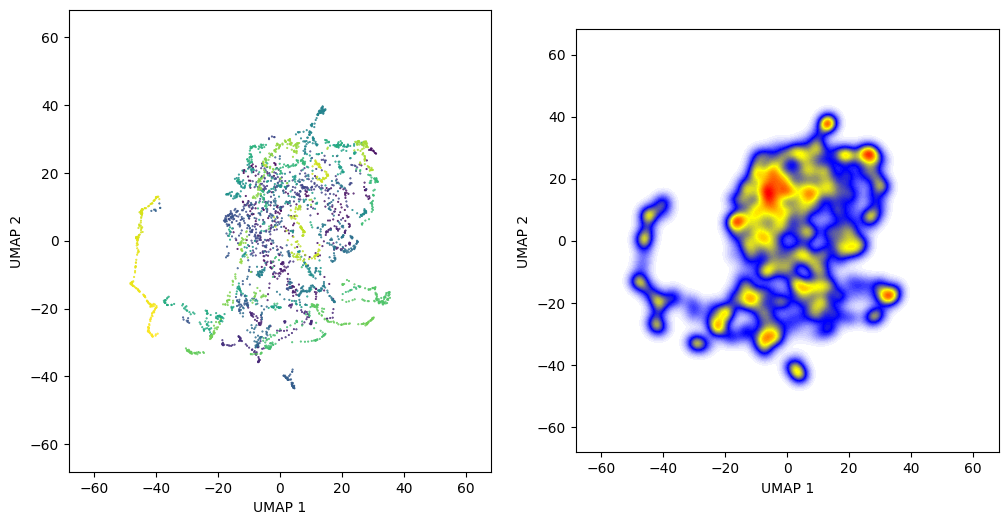

In [22]:
trainy = hdf5storage.loadmat(f'{parameters.projectPath}/{parameters.method}/training_embedding.mat')['trainingEmbedding']
m = np.abs(trainy).max()

sigma=2.0
_, xx, density = mmpy.findPointDensity(trainy, sigma, 511, [-m-20, m+20])

fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].scatter(trainy[:,0], trainy[:,1], marker='.', c=np.arange(trainy.shape[0]), s=1)
axes[0].set_xlim([-m-20, m+20])
axes[0].set_ylim([-m-20, m+20])
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].imshow(density, cmap=mmpy.gencmap(), extent=(xx[0], xx[-1], xx[0], xx[-1]), origin='lower')
fig.show()

# 5.&nbsp; Finding embeddings for all data

In [23]:
tall = time.time()

tfolder = parameters.projectPath+'/%s/'%parameters.method

# Loading training data
with h5py.File(tfolder + 'training_data.mat', 'r') as hfile:
    trainingSetData = hfile['trainingSetData'][:].T

# Loading training embedding
with h5py.File(tfolder+ 'training_embedding.mat', 'r') as hfile:
    trainingEmbedding= hfile['trainingEmbedding'][:].T

if parameters.method == 'TSNE':
    zValstr = 'zVals'
else:
    zValstr = 'uVals'

projectionFiles = glob.glob(parameters.projectPath+'/Projections/*pcaModes.mat')
for i in range(len(projectionFiles)):
    print('Finding Embeddings')
    t1 = time.time()
    print(f'{i+1}/{len(projectionFiles)} : {projectionFiles[i]}')

    # load projections and timestamp metadata for a dataset
    projection_payload = hdf5storage.loadmat(projectionFiles[i])
    projections = projection_payload['projections']
    timestamps = projection_payload.get('real_timestamps')

    # Find Embeddings
    zValues, outputStatistics = mmpy.findEmbeddings(
        projections,
        trainingSetData,
        trainingEmbedding,
        parameters,
        timestamps=timestamps)

    # Save embeddings
    hdf5storage.write(data = {'zValues':zValues}, path = '/', truncate_existing = True,
                    filename = projectionFiles[i][:-4]+f'_{zValstr}.mat', store_python_metadata = False,
                      matlab_compatible = True)

    # Save output statistics
    with open(projectionFiles[i][:-4] + f'_{zValstr}_outputStatistics.pkl', 'wb') as hfile:
        pickle.dump(outputStatistics, hfile)

    del zValues, projections, outputStatistics

print(f'All Embeddings Saved in {time.time()-tall} seconds!')


Finding Embeddings
1/14 : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivity//Projections/Observation_hive1_lower_pcaModes.mat
Finding Wavelets
Wavelet chunk report: kept 2878/4207 samples (68.41%). Retained chunks: 8, skipped chunks: 10, skipped samples: 945.
Wavelet coverage: 2878/4207 samples (68.41%) retained after chunk trimming.
Finding Embeddings
	Loading UMAP Model.
	Loaded.
Embeddings found in 17.88 seconds.
Finding Embeddings
2/14 : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivity//Projections/Observation_hive2_lower_pcaModes.mat
Finding Wavelets
Wavelet chunk report: kept 1649/2003 samples (82.33%). Retained chunks: 4, skipped chunks: 2, skipped samples: 162.
Wavelet coverage: 1649/2003 samples (82.33%) retained after chunk trimming.
Finding Embeddings
	Loading UMAP Model.
	Loaded.
Embeddings found in 10.06 seconds.
Fin

Visualisation of Density Map

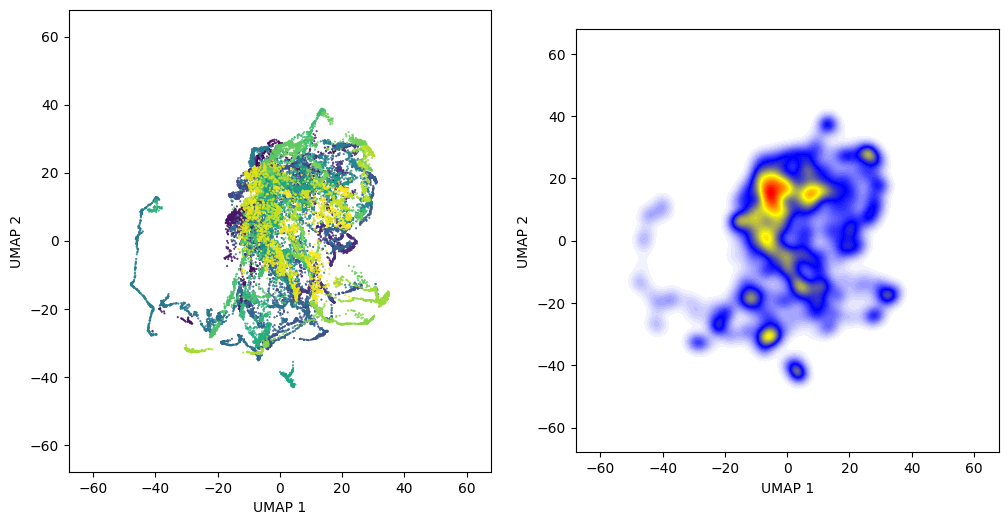

In [24]:
# load all the embeddings
ally = np.array([])
for i in glob.glob(parameters.projectPath+f'/Projections/*_{zValstr}.mat'):
  proj_ally = hdf5storage.loadmat(i)['zValues']
  ally = np.vstack([ally, proj_ally]) if ally.size else proj_ally

m = np.abs(ally).max()


fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].scatter(ally[:,0], ally[:,1], marker='.', c=np.arange(ally.shape[0]), s=1)
axes[0].set_xlim([-m-20, m+20])
axes[0].set_ylim([-m-20, m+20])
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

sigma=2.0
_, xx, density = mmpy.findPointDensity(ally, sigma, 511, [-m-20, m+20])

axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].imshow(density, cmap=mmpy.gencmap(), extent=(xx[0], xx[-1], xx[0], xx[-1]), origin='lower')
fig.show()

# 6.&nbsp; Watershed transform on the density map

In [25]:
# Parameter for Watershed
min_regions = 15

1/14 Loading embedding for Observation_hive1_lower_pcaModes 0.00 seconds.
2/14 Loading embedding for Observation_hive2_lower_pcaModes 0.01 seconds.
3/14 Loading embedding for Observation_hive1_upper_pcaModes 0.01 seconds.
4/14 Loading embedding for SharpNight_hive1_upper_pcaModes 0.01 seconds.
5/14 Loading embedding for SoftNight_hive1_upper_pcaModes 0.01 seconds.
6/14 Loading embedding for Observation_hive2_upper_pcaModes 0.01 seconds.
7/14 Loading embedding for SharpNight_hive2_upper_pcaModes 0.01 seconds.
8/14 Loading embedding for SharpDay_hive1_upper_pcaModes 0.01 seconds.
9/14 Loading embedding for Idle_hive1_upper_pcaModes 0.01 seconds.
10/14 Loading embedding for SoftDay_hive1_upper_pcaModes 0.02 seconds.
11/14 Loading embedding for SoftDay_hive2_upper_pcaModes 0.02 seconds.
12/14 Loading embedding for Idle_hive2_upper_pcaModes 0.02 seconds.
13/14 Loading embedding for SharpDay_hive2_upper_pcaModes 0.02 seconds.
14/14 Loading embedding for Constant_hive2_upper_pcaModes 0.02 sec

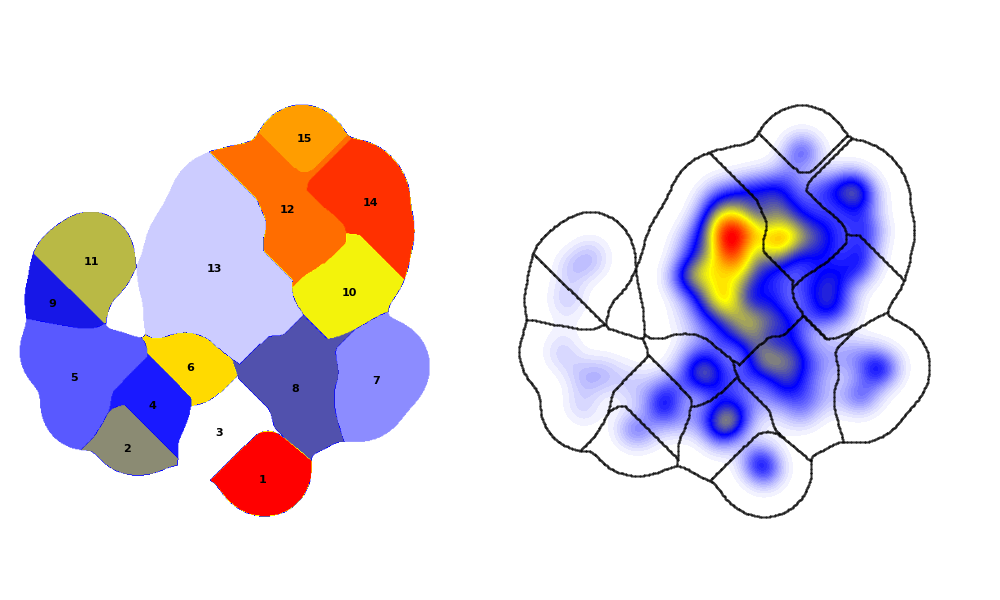

In [ ]:
startsigma = 1.0 if parameters.method == 'TSNE' else 1.0
mmpy.findWatershedRegions(parameters, minimum_regions=min_regions, startsigma=startsigma, pThreshold=[0.33, 0.67], saveplot=True, endident = '*_pcaModes.mat')

# wshedTransform() names the file zWshed{numRegs}.png, where numRegs is the actual region
# count it converged to (<= min_regions, since it keeps raising sigma until the count drops
# to or below the target) -- not min_regions itself. Runs with different min_regions values
# leave multiple zWshed*.png files behind, and glob(...)[0] just grabs whichever one glob
# happens to list first, not necessarily the one from this run. Pick the file whose region
# count is the closest match at or below the current min_regions instead.
wshed_pngs = glob.glob(f'{parameters.projectPath}/{parameters.method}/zWshed*.png')
region_counts = {}
for p in wshed_pngs:
    m = re.search(r'zWshed(\d+)\.png$', os.path.basename(p))
    if m:
        region_counts[p] = int(m.group(1))

candidates = {p: n for p, n in region_counts.items() if n <= min_regions}
if not candidates:
    raise FileNotFoundError(
        f"No zWshed*.png found with region count <= min_regions ({min_regions}) in "
        f"{parameters.projectPath}/{parameters.method}/"
    )
wshed_png = max(candidates, key=candidates.get)
print(f"Using {wshed_png} ({candidates[wshed_png]} regions) for min_regions={min_regions}.")
Image(wshed_png)


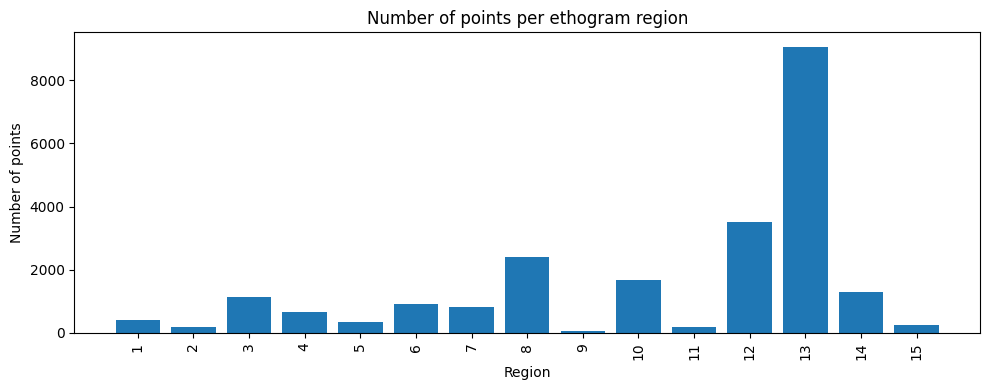

In [27]:
# wregs : 1D array containing the region label for each point (0 = background, 1..K = regions)
wshedfile = hdf5storage.loadmat(f'{parameters.projectPath}/{parameters.method}/zVals_wShed_groups.mat')
wregs = wshedfile['watershedRegions'].flatten().astype(int)
unique, counts = np.unique(wregs, return_counts=True)

# Put in DataFrame format for easier reading
df_counts = pd.DataFrame({
    "region": unique.astype(int),
    "n_points": counts.astype(int)
})

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(df_counts["region"], df_counts["n_points"])

ax.set_xlabel("Region")
ax.set_ylabel("Number of points")
ax.set_title("Number of points per ethogram region")

ax.set_xticks(df_counts["region"])
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


In [28]:
from pathlib import Path
PROJECT_DIR = Path(projectPath)
RESULTS_DIR = PROJECT_DIR / "UMAP"
PROJECTIONS_DIR = PROJECT_DIR / "Projections"
WSHED_PATH = RESULTS_DIR / "zVals_wShed_groups.mat"

total_embeddings = 0
# retrieve the UMAP embeddings for all datapoints across all datasets
for dataset_name in dataset_names:
    dataset_mat_file = hdf5storage.loadmat(f'{PROJECTIONS_DIR}/{dataset_name}_pcaModes_uVals.mat')
    dataset_embeddings = dataset_mat_file['zValues']
    print(f"Dataset {dataset_name} embeddings shape: {dataset_embeddings.shape}")
    total_embeddings += dataset_embeddings.shape[0]

    print(f"Keys in the embeddings file: {list(dataset_mat_file.keys())}")
    outputStats = np.load(f'{PROJECTIONS_DIR}/{dataset_name}_pcaModes_uVals_outputStatistics.pkl', allow_pickle=True)
    print(f"Keys in the output statistics file: {list(outputStats.keys())}")
    kept_indices = outputStats['keptIdx']
    print(f"Kept indices shape: {kept_indices.shape}")
    print(kept_indices[:10])  # Print the first 10 kept indices
    pcaModesFile = hdf5storage.loadmat(f'{PROJECTIONS_DIR}/{dataset_name}_pcaModes.mat')
    print(f"Keys in the PCA modes file: {list(pcaModesFile.keys())}")
    timestamps = pcaModesFile['real_timestamps']
    print(f"Timestamps shape: {timestamps.shape}")
    print(timestamps[:10])  # Print the first 10 timestamps

wshedfile = hdf5storage.loadmat(str(WSHED_PATH))
print(f"Watershed file keys: {list(wshedfile.keys())}")
zvalues = wshedfile['zValues']
print(f"zValues shape: {zvalues.shape}")
print(f"In total, we got {total_embeddings} embeddings across all datasets, and the watershed file has {zvalues.shape[0]} embeddings.")

Dataset Observation_hive1_upper embeddings shape: (3128, 2)
Keys in the embeddings file: ['zValues']
Keys in the output statistics file: ['training_mean', 'training_scale', 'keptIdx', 'waveletCoverage']
Kept indices shape: (3128,)
[30 31 32 33 34 35 36 37 38 39]
Keys in the PCA modes file: ['projections', 'real_timestamps', 'shifted_timestamps']
Timestamps shape: (4505,)
[1726237800000000000 1726238400000000000 1726239000000000000
 1726239600000000000 1726240200000000000 1726240800000000000
 1726260000000000000 1726260600000000000 1726261200000000000
 1726261800000000000]
Dataset Observation_hive1_lower embeddings shape: (2878, 2)
Keys in the embeddings file: ['zValues']
Keys in the output statistics file: ['training_mean', 'training_scale', 'keptIdx', 'waveletCoverage']
Kept indices shape: (2878,)
[30 31 32 33 34 35 36 37 38 39]
Keys in the PCA modes file: ['projections', 'real_timestamps', 'shifted_timestamps']
Timestamps shape: (4207,)
[1726237800000000000 1726238400000000000 172623

# 7.&nbsp; Ethogram Interpretation Tools

## Region Timeline


In [29]:
df_nat = []

for i, (key, df) in enumerate(exps_dfs_dropna.items()):

    df = df.copy()

    # 1) Save the real timestamp
    df["real_timestamp"] = df.index

    # 2) add a source id column
    df["source_id"] = f"{key[0]}_hive{key[1]}_{key[2]}"

    df_nat.append(df)

# 3) concatenate all dataframes into one
df_nat = pd.concat(df_nat, axis=0)
df_nat = df_nat.sort_index()

print(df_nat[["real_timestamp", "source_id"]].tail())

                                real_timestamp           source_id      
datetime                                                                
2025-01-19 15:20:00+00:00 2025-01-19 15:20:00+00:00  SoftDay_hive1_upper
2025-01-19 15:30:00+00:00 2025-01-19 15:30:00+00:00  SoftDay_hive1_upper
2025-01-19 15:40:00+00:00 2025-01-19 15:40:00+00:00  SoftDay_hive1_upper
2025-01-19 15:50:00+00:00 2025-01-19 15:50:00+00:00  SoftDay_hive1_upper
2025-01-19 16:00:00+00:00 2025-01-19 16:00:00+00:00  SoftDay_hive1_upper


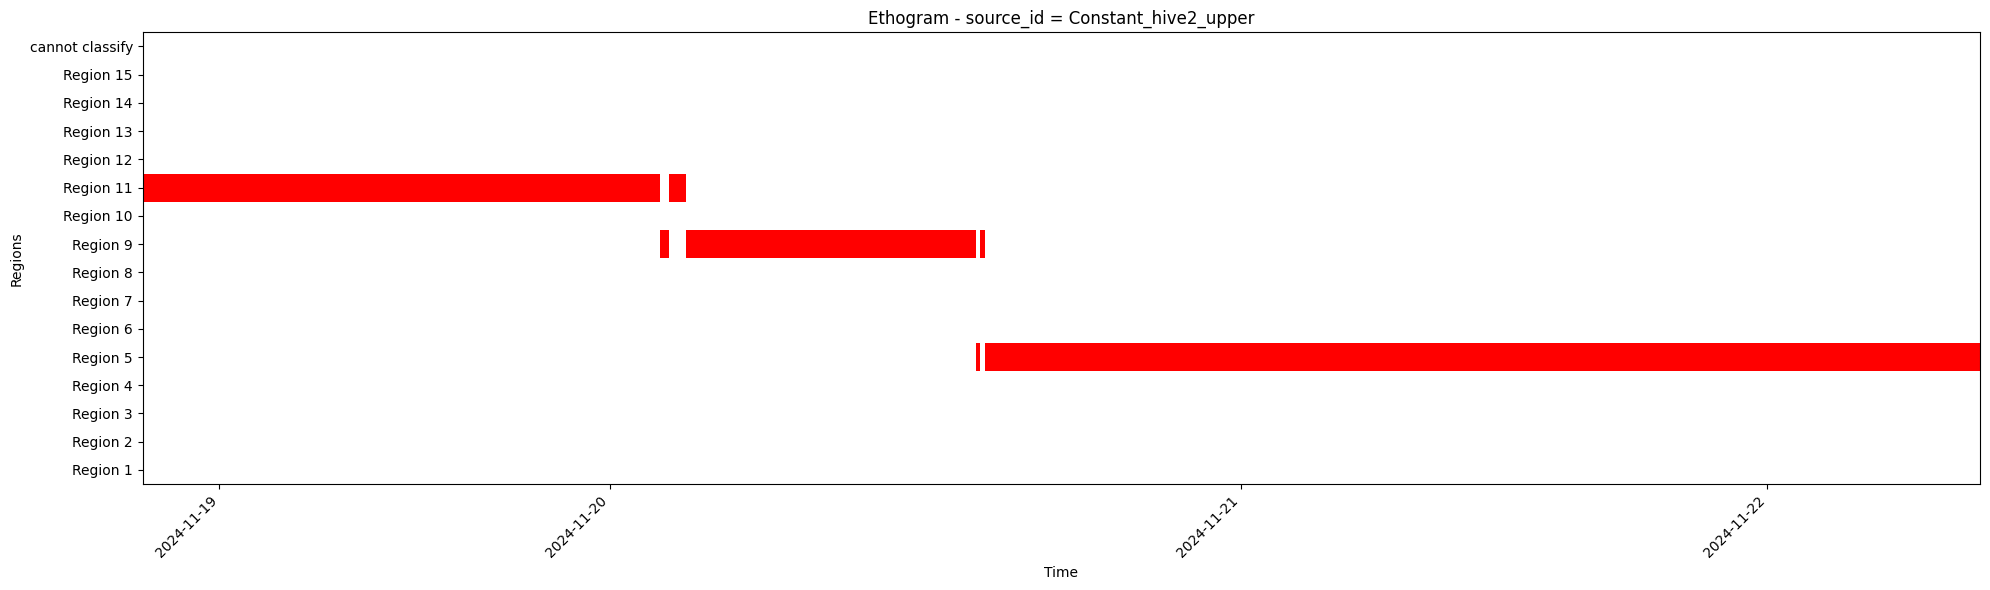

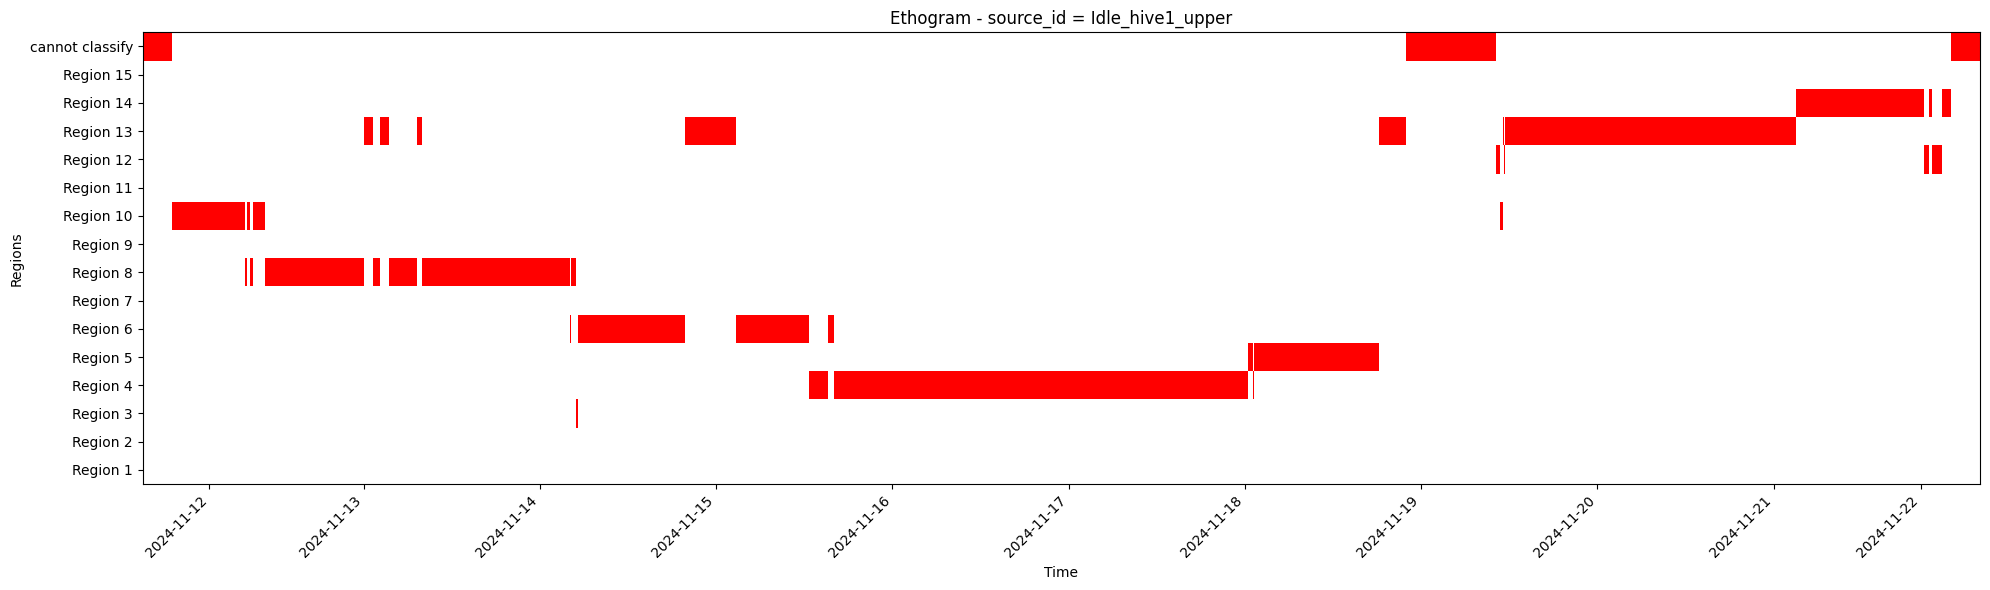

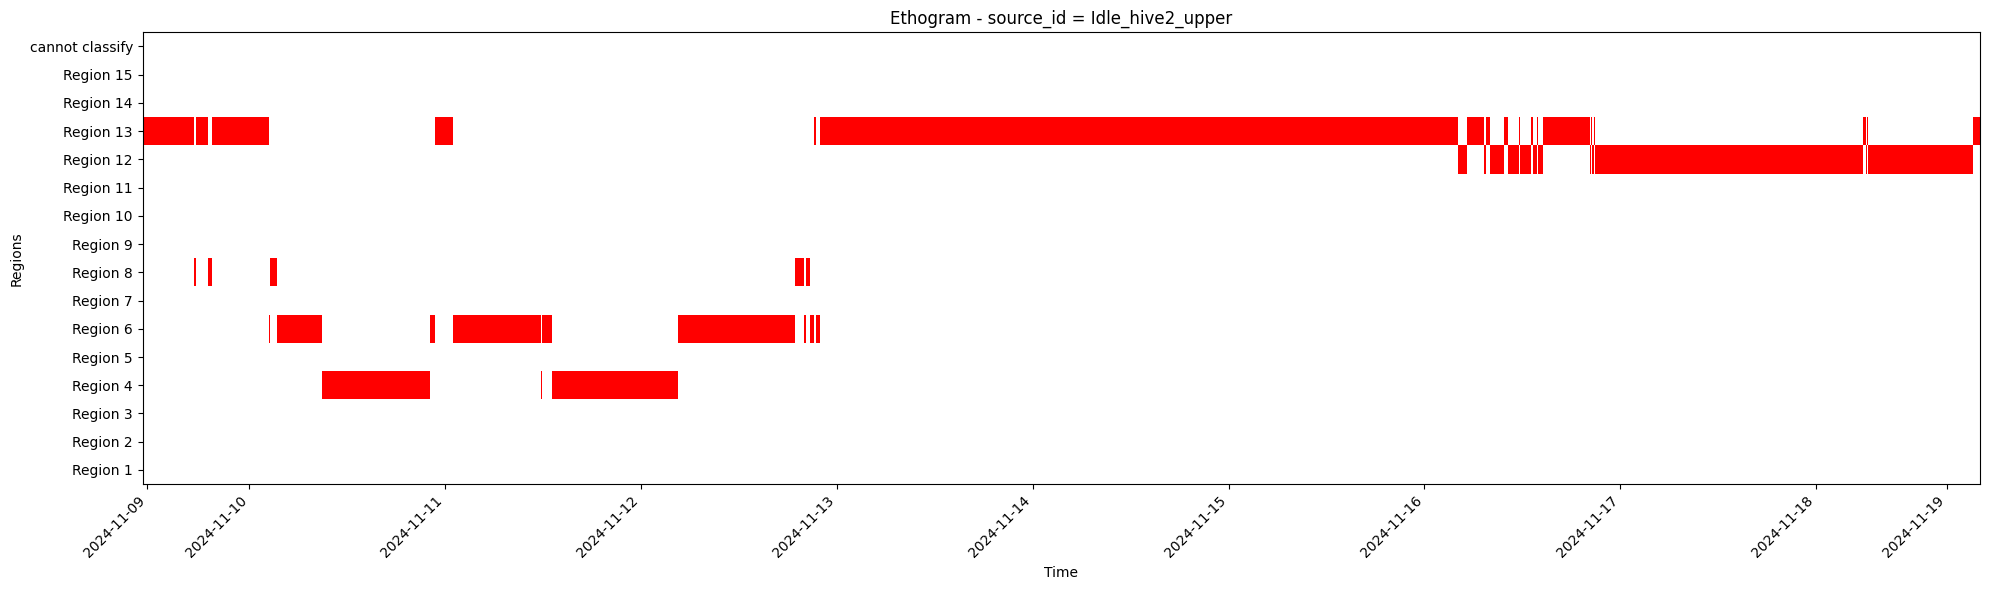

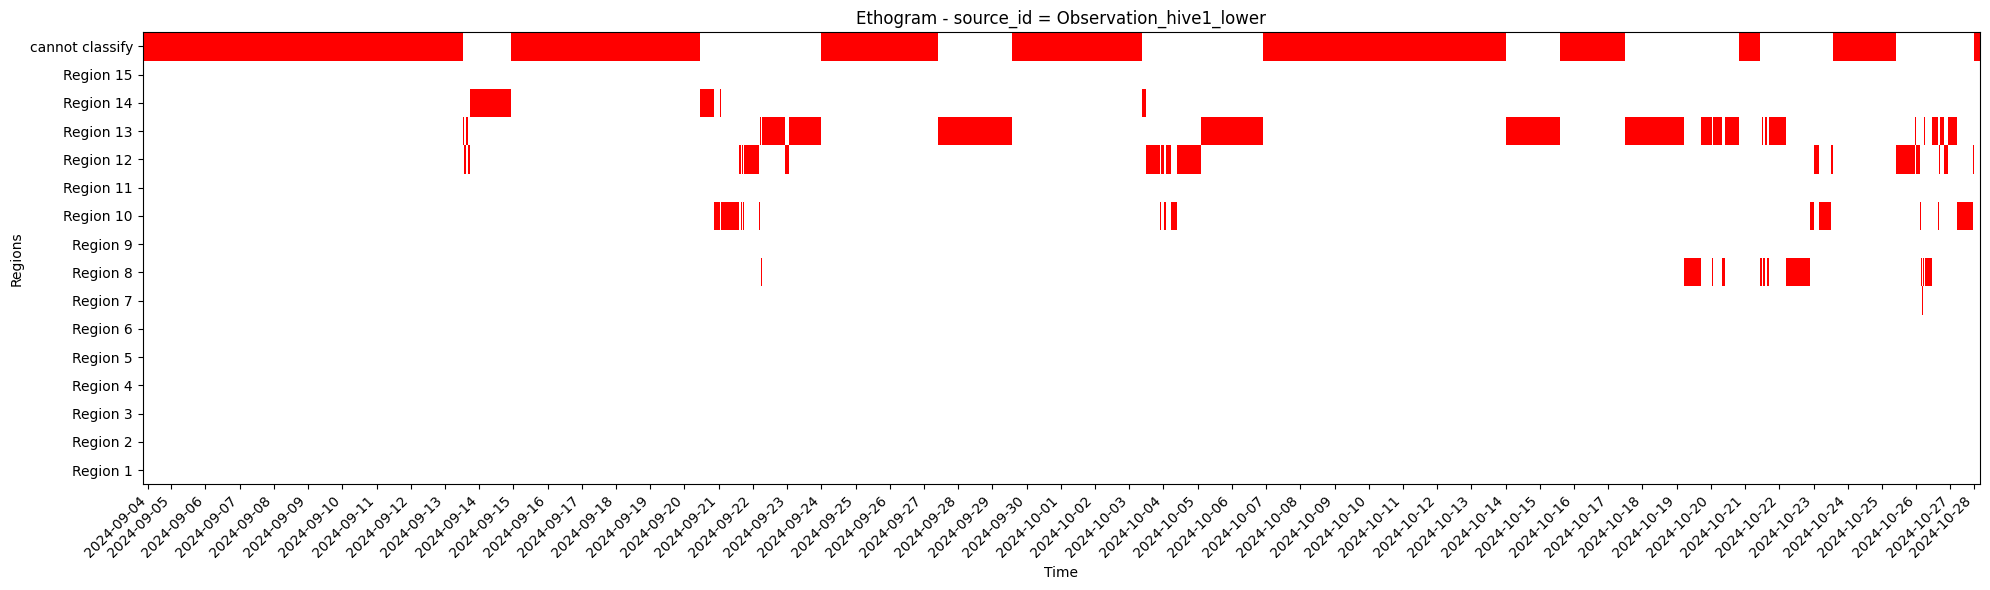

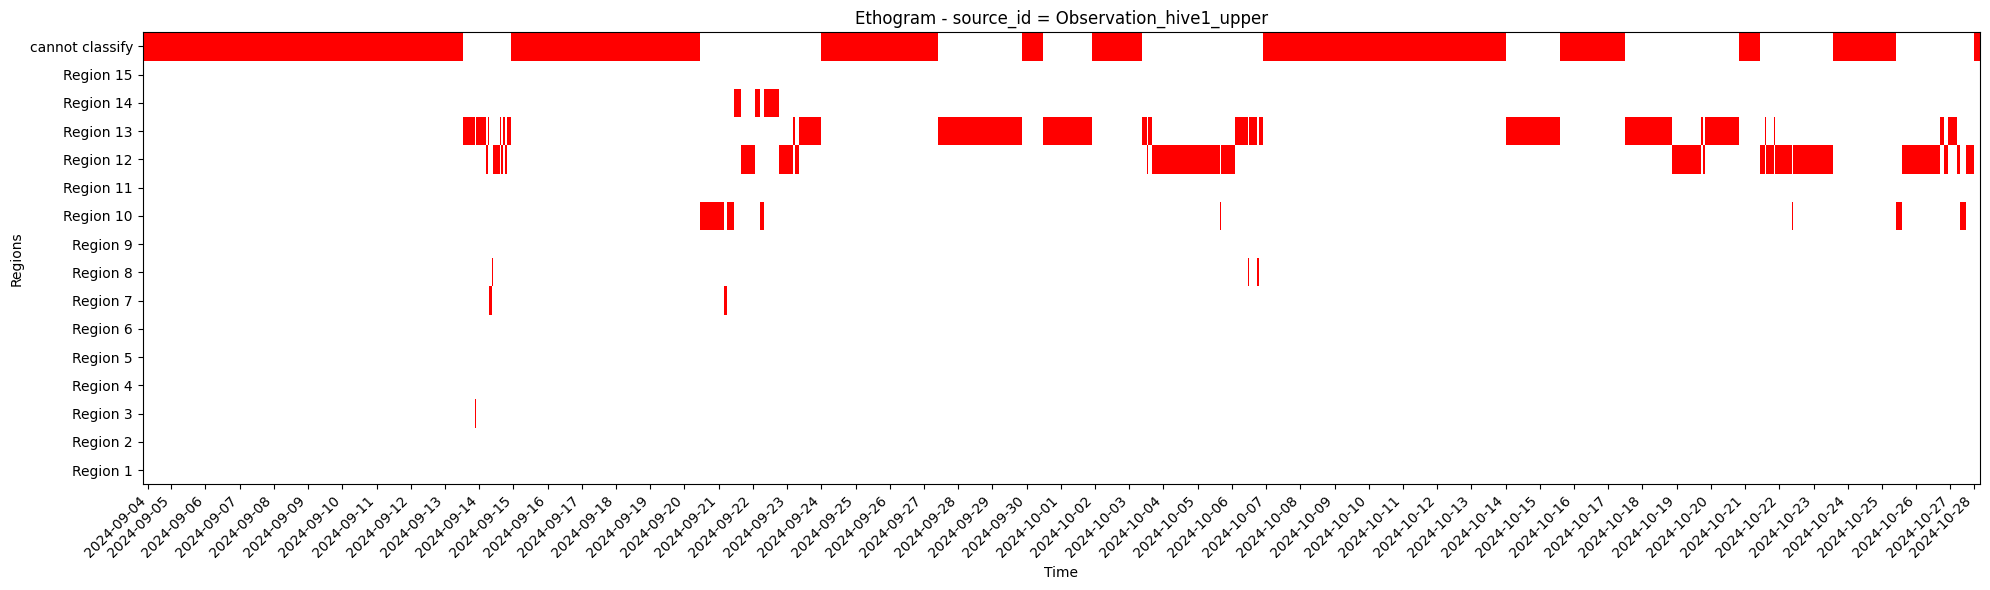

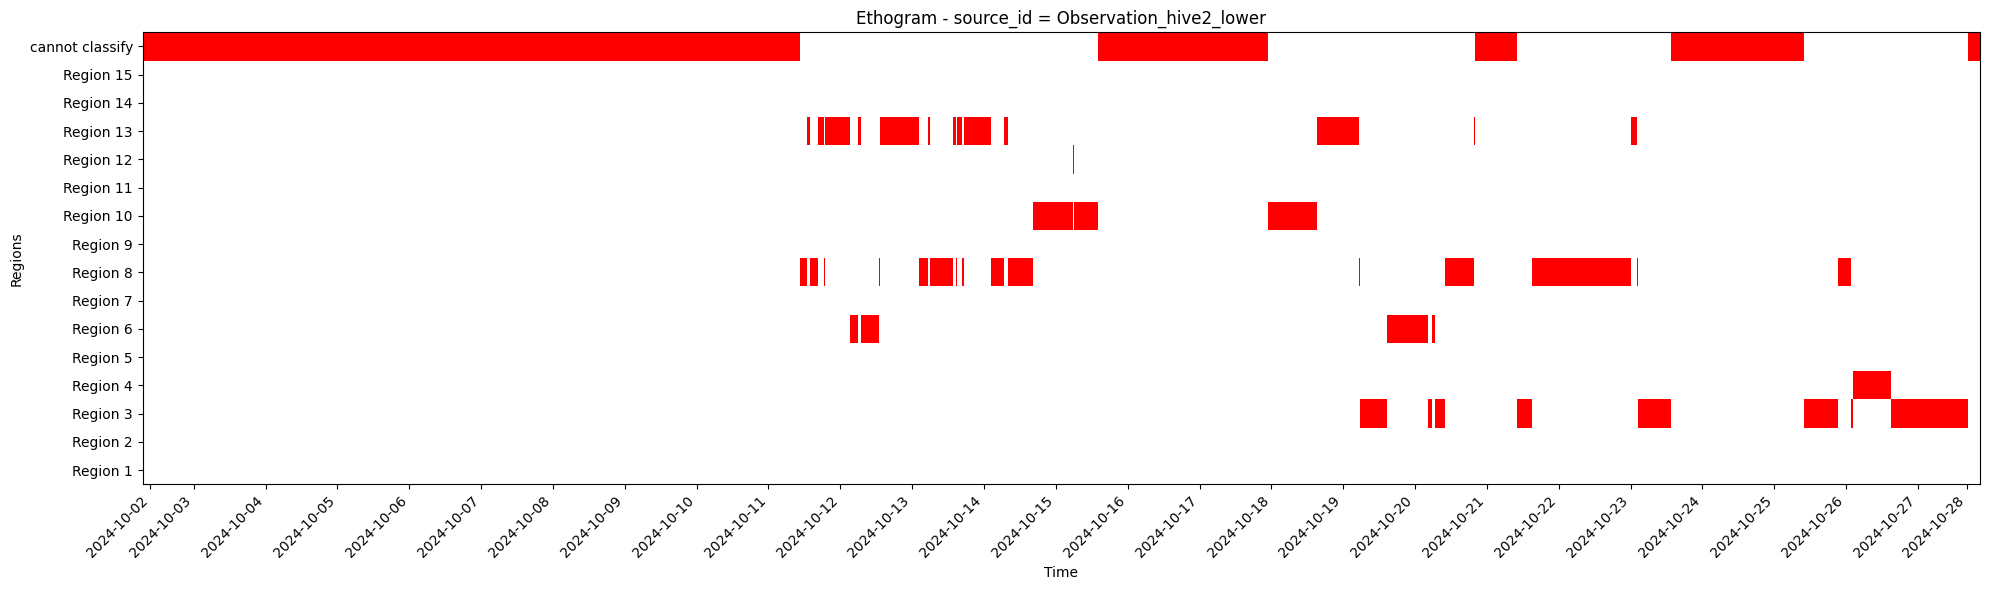

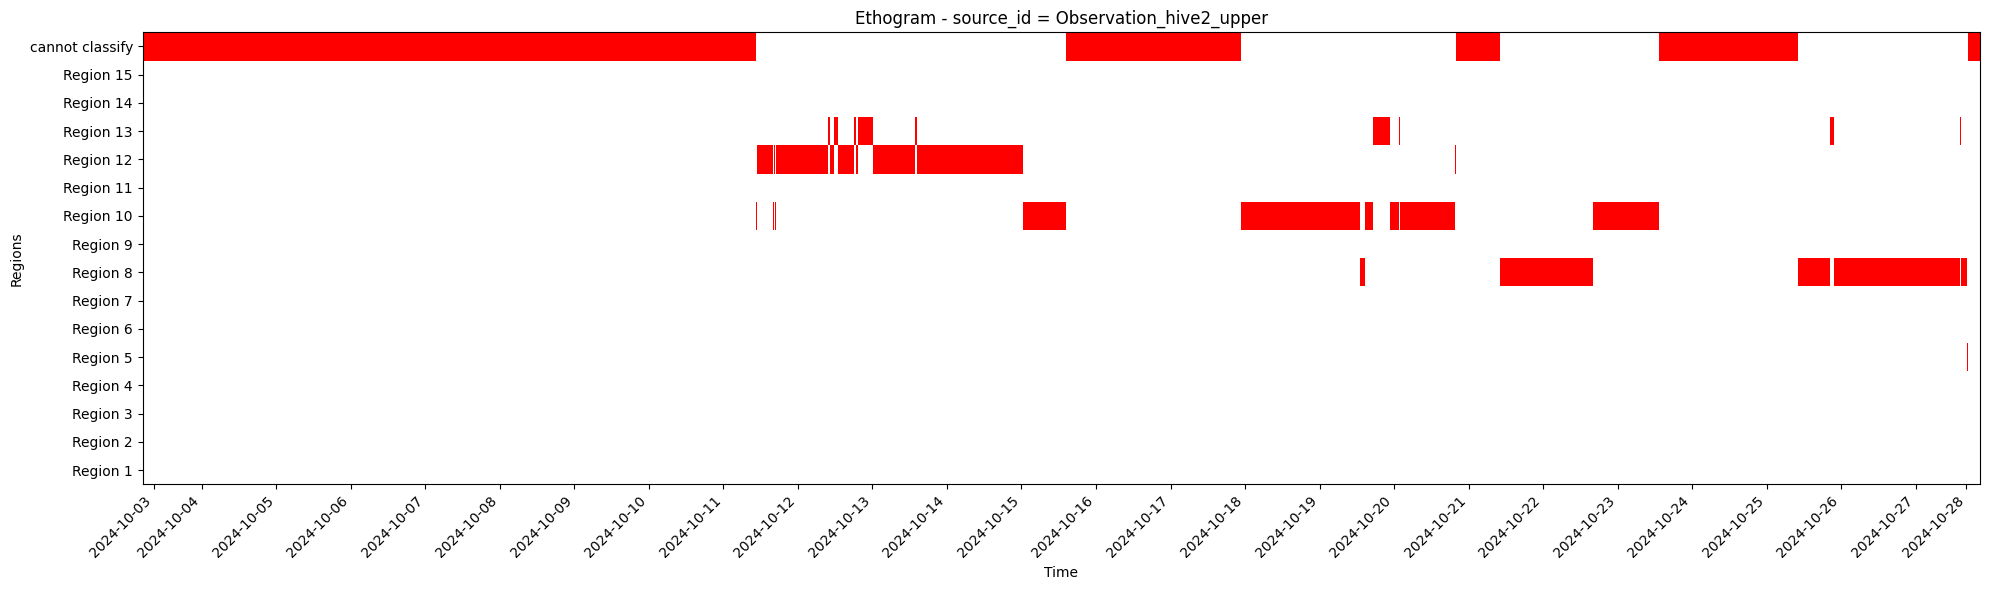

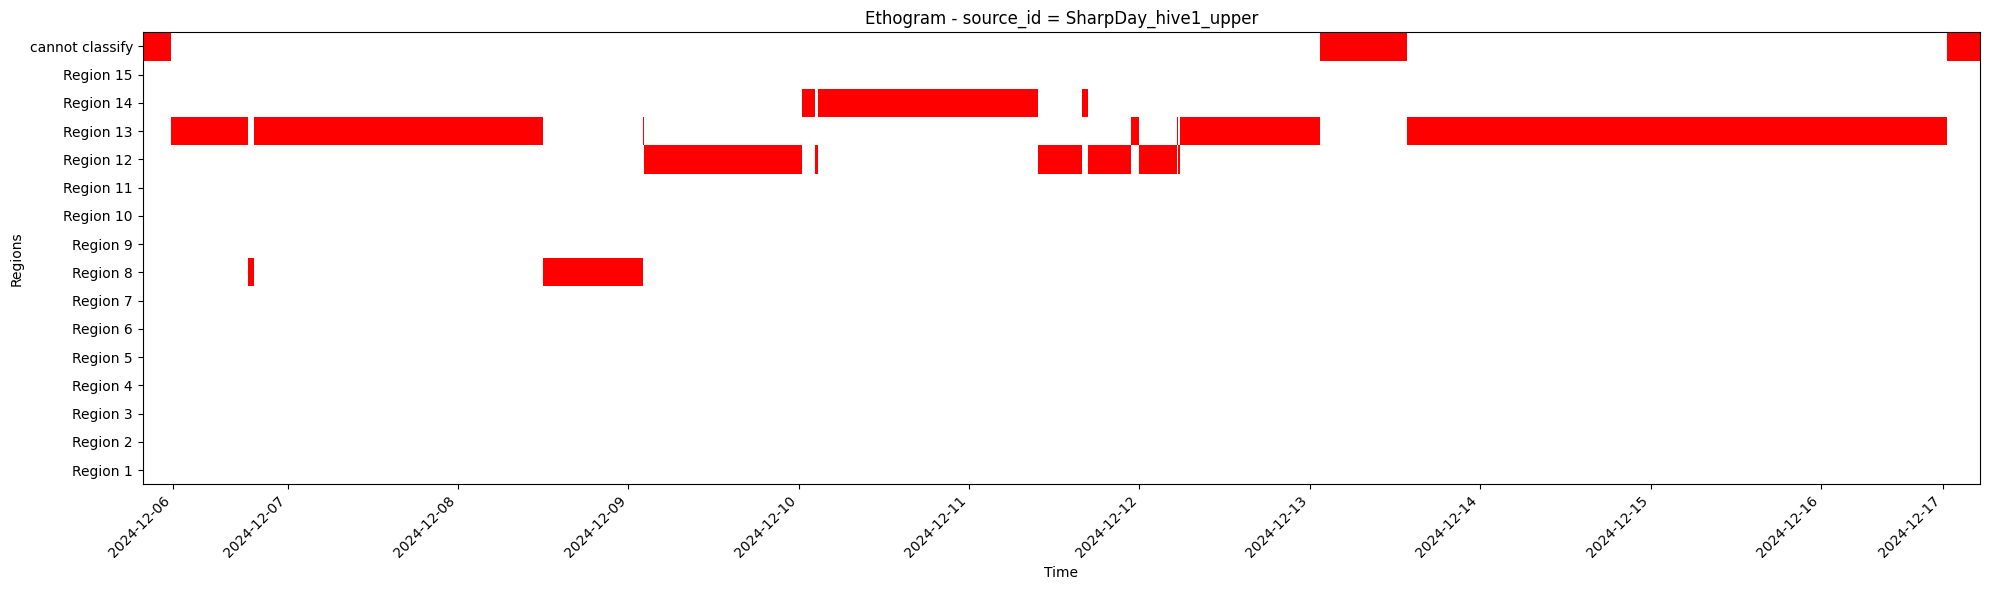

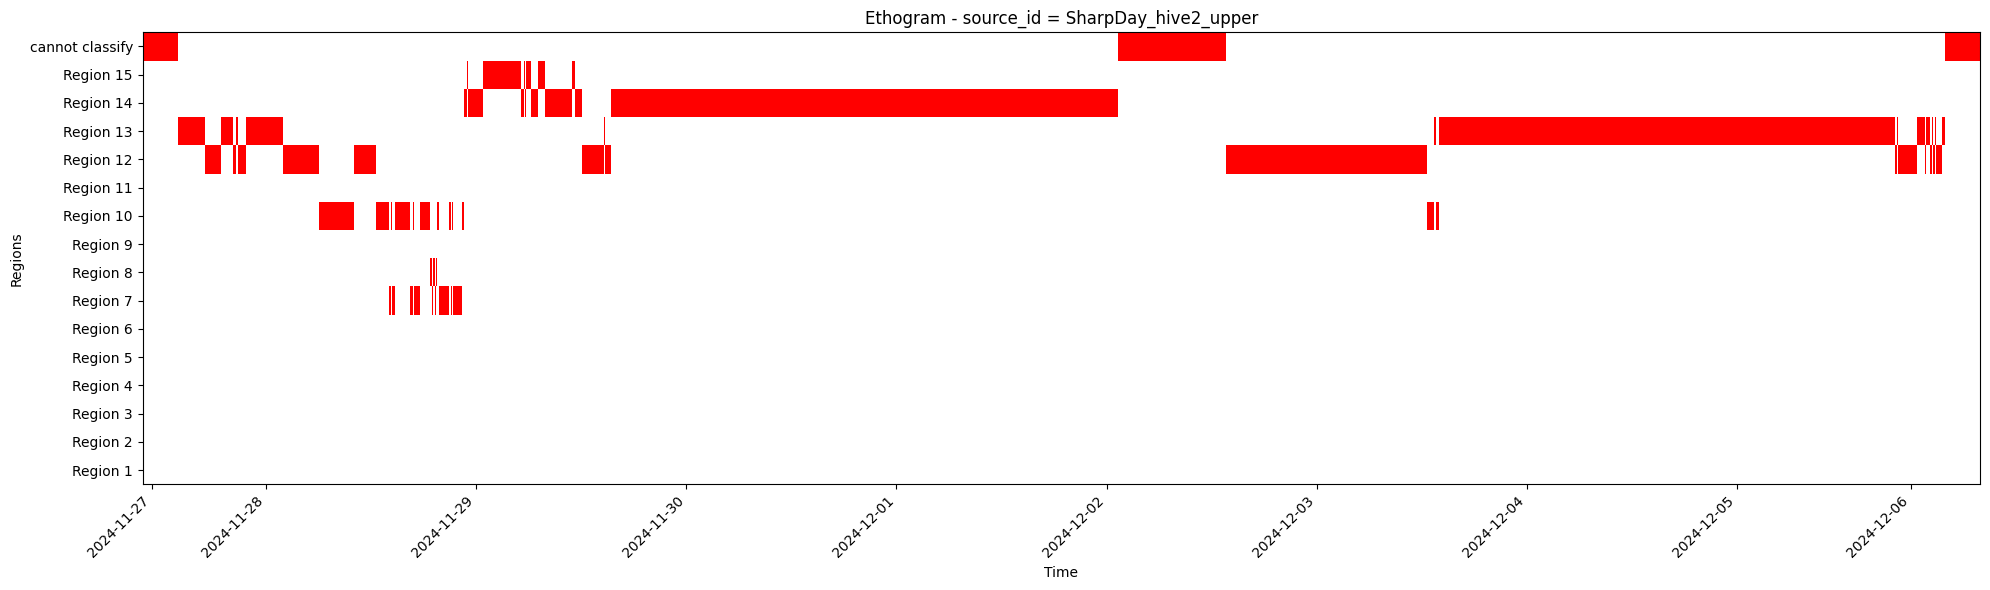

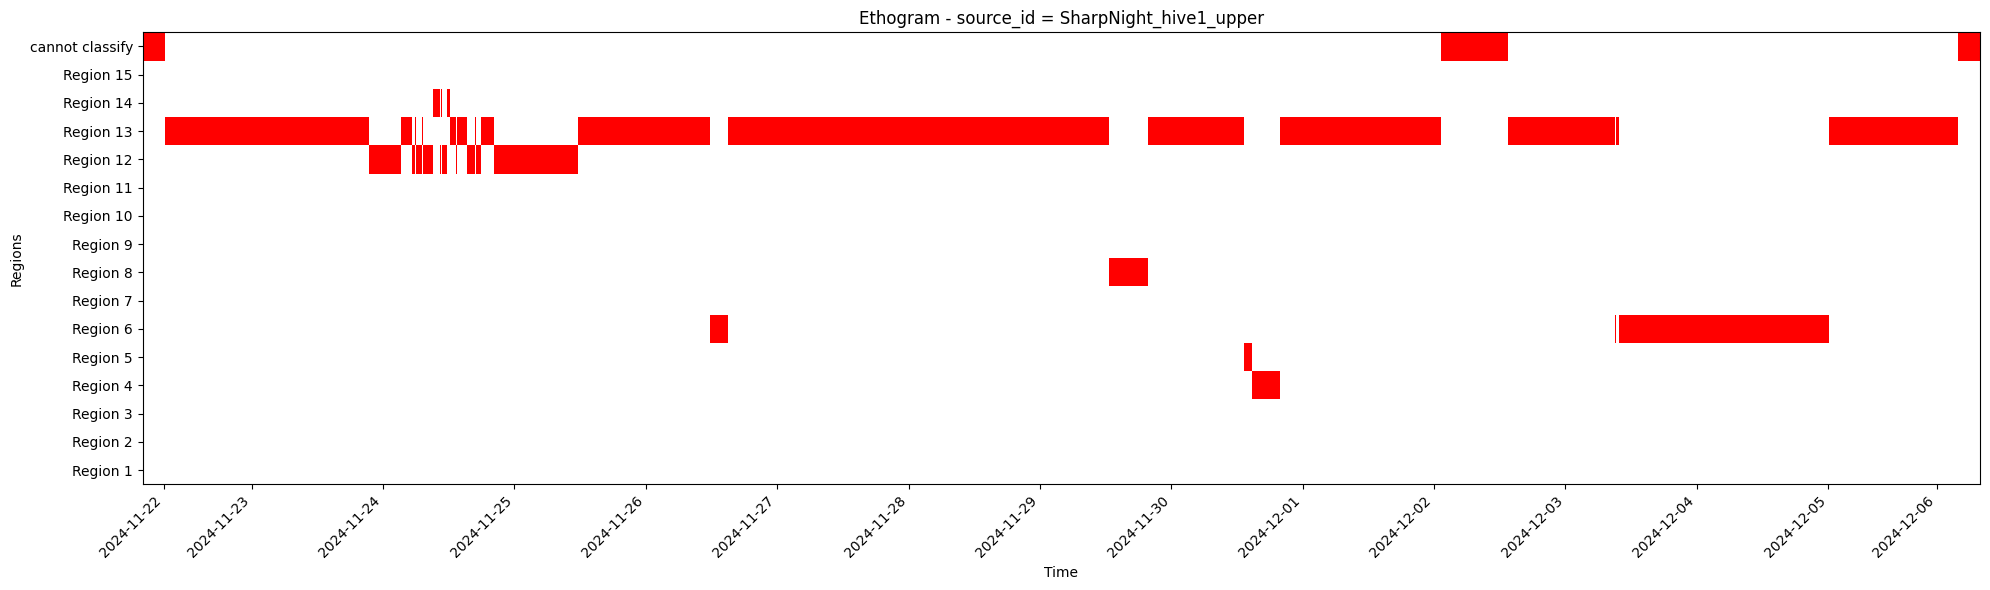

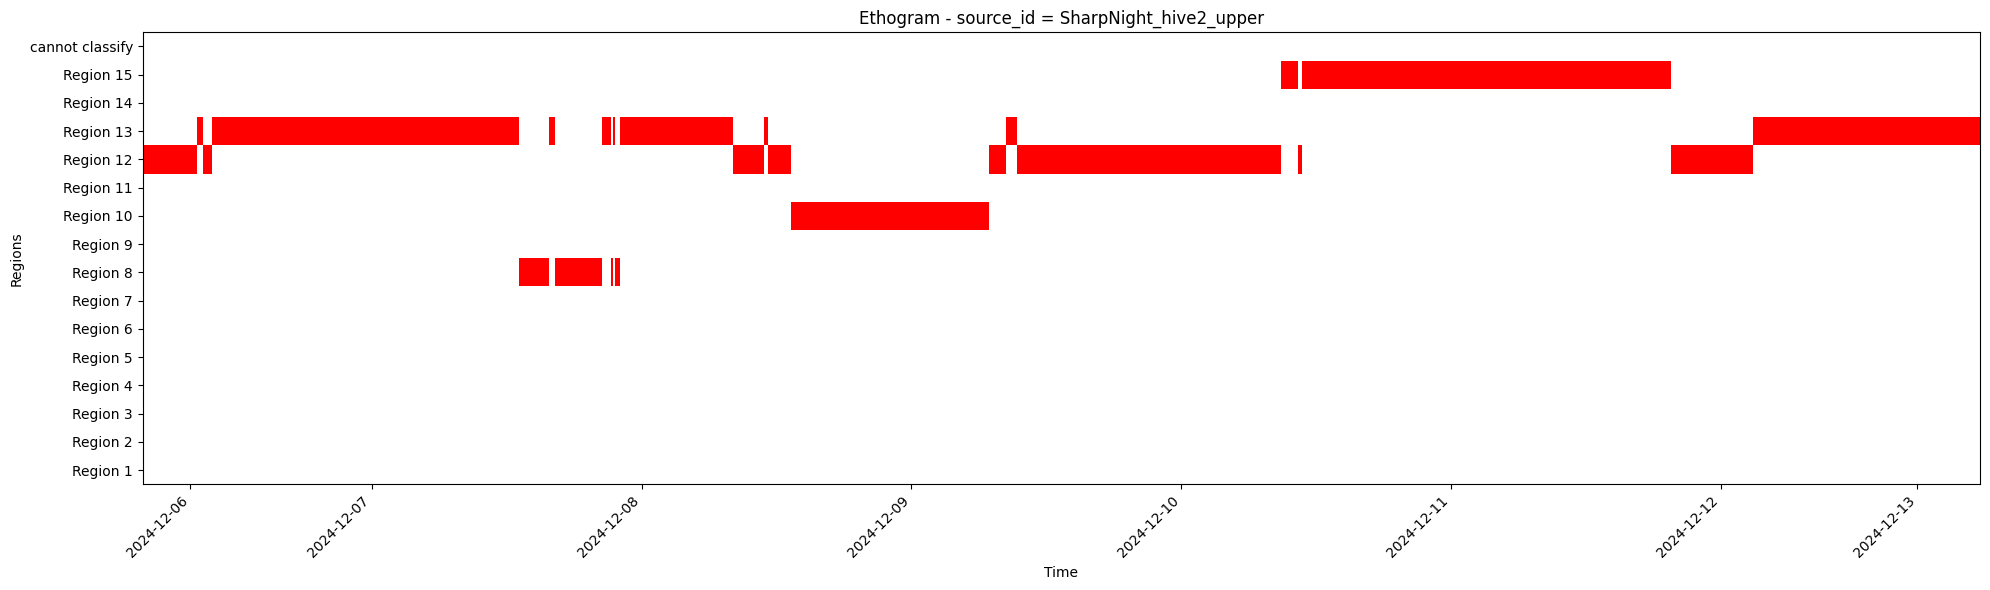

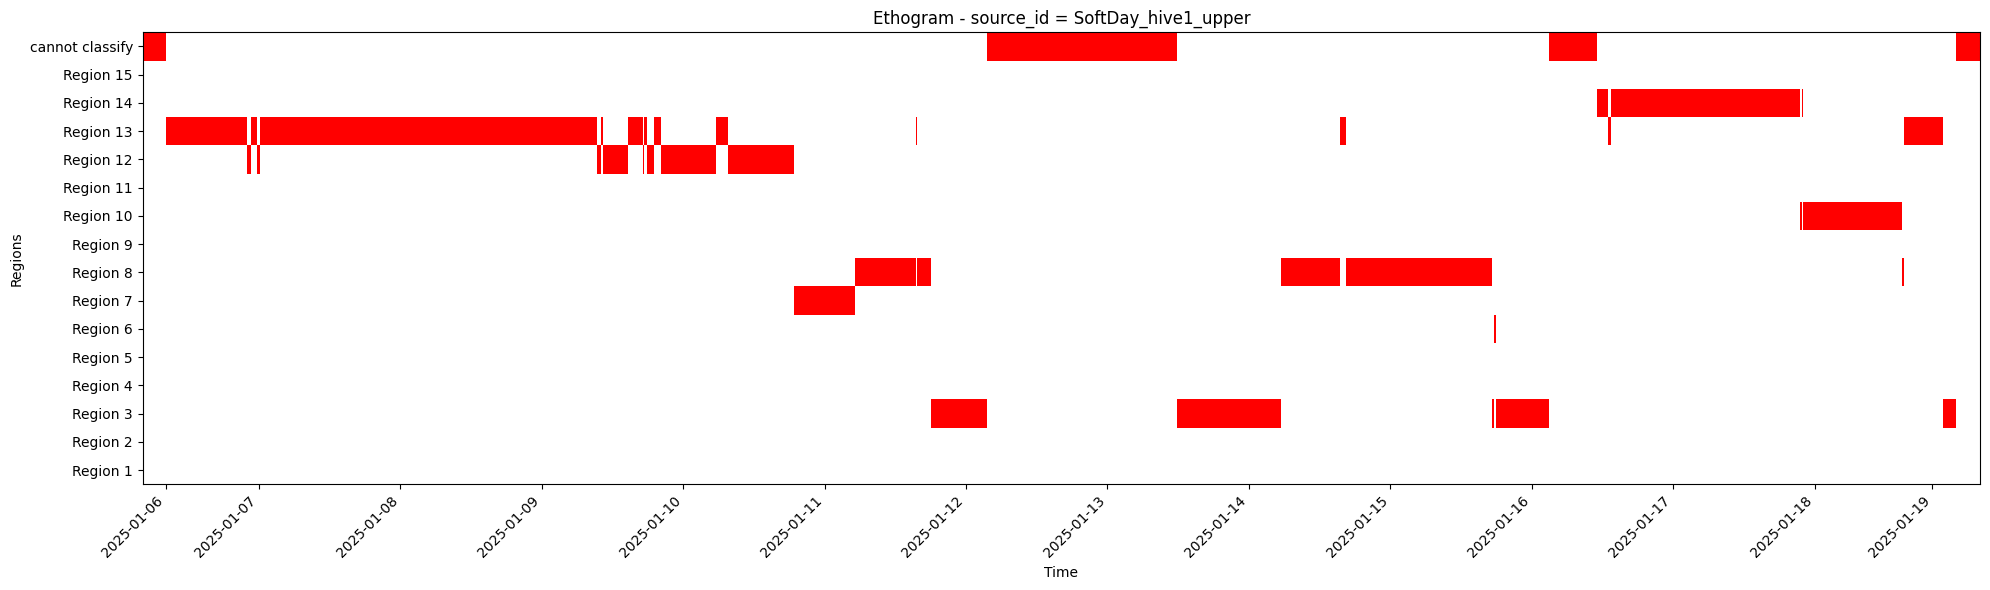

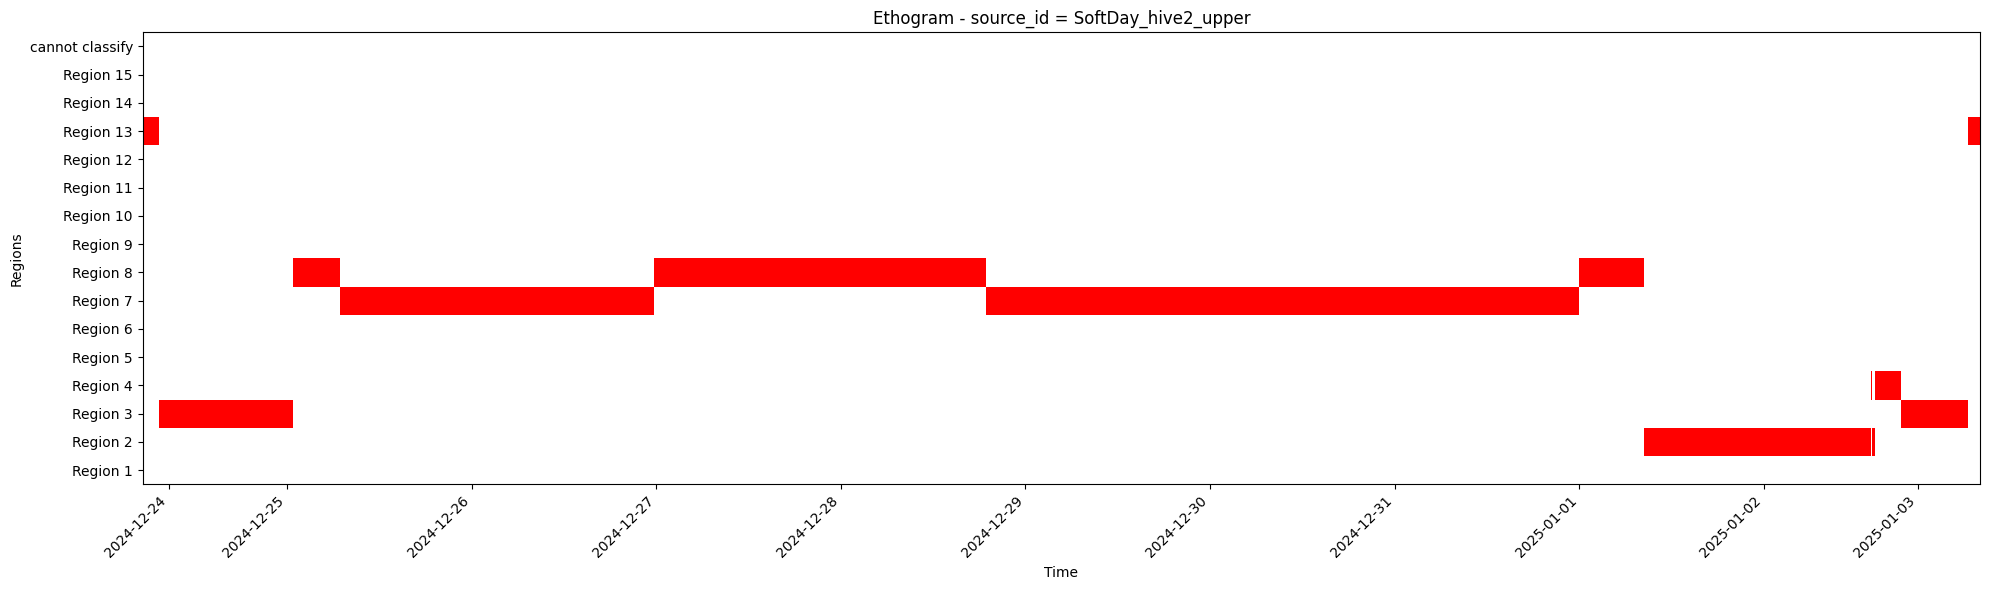

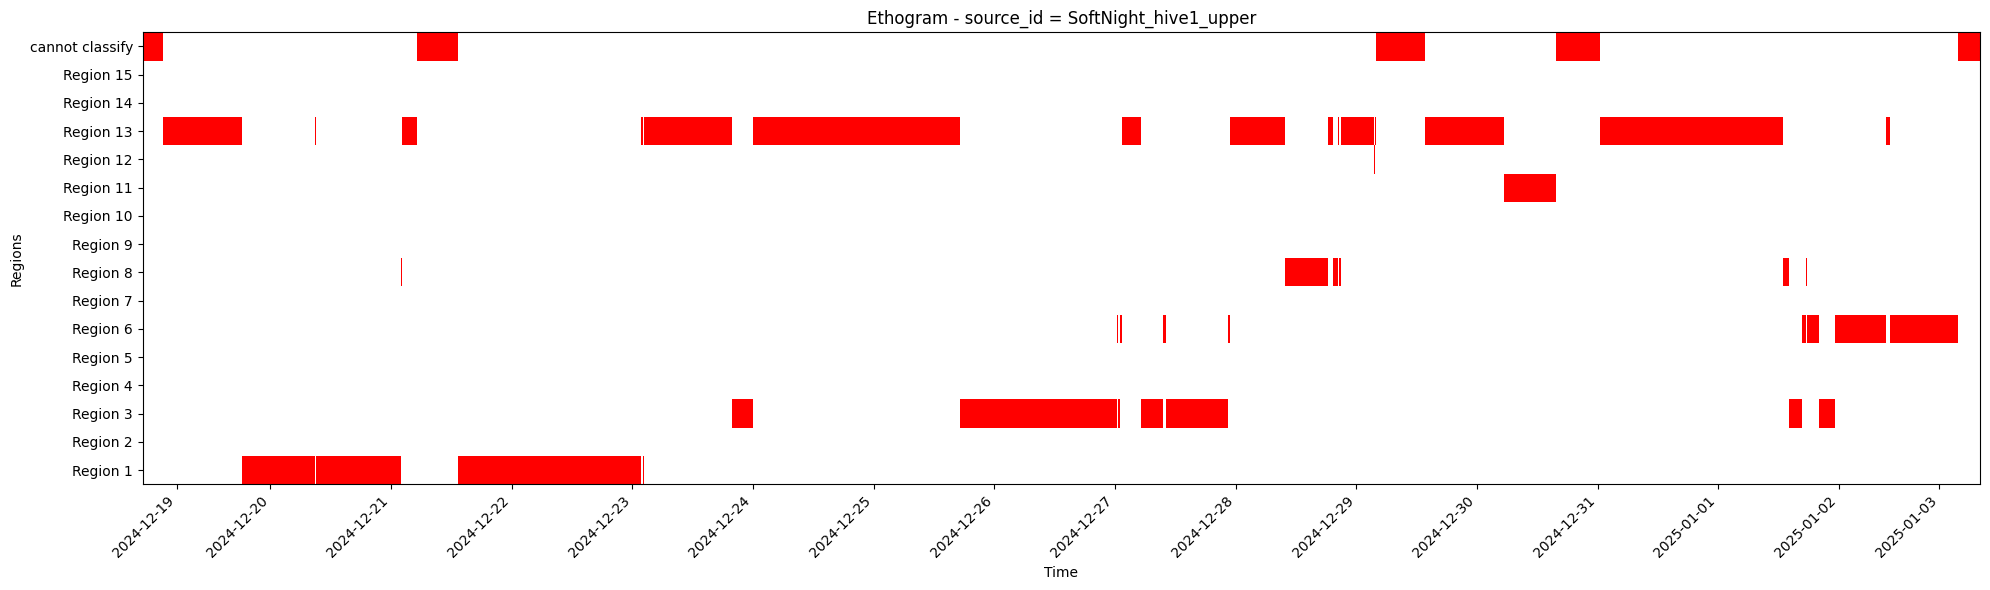

In [30]:
# --- Load kept indices from the embedding run, if available ---
# Load region assignments for all datasets from the watershed file. mmpy.findWatershedRegions
# concatenates each dataset's embeddings in whatever order glob.glob() returns them (filesystem-
# dependent -- NOT alphabetical, and NOT full_dts's insertion order), but it records the *true*
# per-dataset order and lengths as zValNames/zValLens inside the wshed file itself. Relying on a
# separately-sorted file listing (then zipping positionally against full_dts) silently misaligned
# every dataset once files stopped being named "dataset_0", "dataset_1", ... numerically.
wshedfile = hdf5storage.loadmat(f'{parameters.projectPath}/{parameters.method}/zVals_wShed_groups.mat')
wregs = wshedfile['watershedRegions'].flatten().astype(float)
zval_names = [str(np.asarray(n).ravel()[0]) for n in wshedfile['zValNames'].flatten()]
zval_lens = wshedfile['zValLens'].flatten().astype(int)
zval_offsets = np.cumsum([0] + zval_lens[:-1].tolist())

# Map each dataset's source_id (the same string used to name its pcaModes.mat file) to its
# (offset, length) block within wregs/zValues.
source_id_blocks = {}
for name, length, offset in zip(zval_names, zval_lens, zval_offsets):
    stem = name[:-len('_pcaModes')] if name.endswith('_pcaModes') else name
    source_id_blocks[stem] = (offset, length)

# Total number of watershed regions across the whole (all-datasets) map, so every
# dataset's ethogram uses the same fixed row count -- regions a given dataset never
# visits still get an (empty) row instead of being dropped from the y-axis entirely.
finite_wregs = wregs[np.isfinite(wregs) & (wregs > 0)]
total_nreg = int(finite_wregs.max()) if finite_wregs.size else 0

for i, (key, full_dts_s) in enumerate(full_dts.items()):
    source_id = f"{key[0]}_hive{key[1]}_{key[2]}"
    stats_file = f'{parameters.projectPath}/Projections/{source_id}_pcaModes_uVals_outputStatistics.pkl'
    pca_file = f'{parameters.projectPath}/Projections/{source_id}_pcaModes.mat'

    with open(stats_file, 'rb') as hfile:
        outputStatistics = pickle.load(hfile)

    pca_data = hdf5storage.loadmat(pca_file)

    keptIdx = np.asarray(outputStatistics.keptIdx).astype(int).ravel()
    real_ts = pd.to_datetime(pca_data['real_timestamps'], utc=True)
    real_ts = real_ts[keptIdx]  # Filter real timestamps to only those that were kept

    offset, length = source_id_blocks[source_id]
    assert length == len(keptIdx), (
        f"keptIdx length ({len(keptIdx)}) doesn't match the watershed block length ({length}) "
        f"for {source_id}; the wshed file may be stale relative to the Projections folder."
    )
    region_classification = wregs[offset:offset + length]  # As wregs is ordered by dataset

    full_dts_s = pd.to_datetime(full_dts_s)

    regions_lin = []
    for t in full_dts_s:
        if t in real_ts:
            idx = np.where(real_ts == t)[0][0]
            regions_lin.append(region_classification[idx])
            df_nat.loc[(df_nat["real_timestamp"] == t) & (df_nat["source_id"] == source_id), "region"] = region_classification[idx]
        else:
            regions_lin.append(np.nan)
            df_nat.loc[(df_nat["real_timestamp"] == t) & (df_nat["source_id"] == source_id), "region"] = np.nan

    # Build ethogram from regions_lin
    w_arr = np.asarray(regions_lin)
    nreg = total_nreg
    E = np.zeros((nreg + 1, w_arr.size), dtype=np.uint8)
    for j, v in enumerate(w_arr):
        if not np.isfinite(v) or v <= 0:
            E[-1, j] = 1
        else:
            rid = int(round(v))
            if 1 <= rid <= nreg:
                E[rid - 1, j] = 1
            else:
                E[-1, j] = 1

    # Build day boundaries from the shared linear timestamps (even spacing)
    dates = full_dts_s.date
    change = np.flatnonzero(np.diff(dates.astype('datetime64[D]'))) + 1
    boundaries = list(change) + [len(full_dts_s)]
    dnames, counts, start = [], [], 0
    for b in boundaries:
        dnames.append(str(pd.to_datetime(dates[start]).date()))
        counts.append(b - start)
        start = b
    bounds = np.cumsum(counts).tolist()
    # Build & plot using the shared full_dts timeline
    plot_ethogram(E, nreg, dnames, bounds, counts, title=f"Ethogram - source_id = {source_id}", timestamps=full_dts_s)


## Plot 100 points around barycentre

In [31]:
# Remove all rows from df_nat where the region is NaN
df_nat = df_nat.dropna(subset=["region"])
# Verify alignment
assert len(df_nat) == len(wregs), f"df_nat et wregs doivent avoir la même longueur. df_nat: {len(df_nat)}, wregs: {len(wregs)}"

# Add UMAP coords
rounded_ally = [[round(x,2) for x in row] for row in ally]
df_nat["UMAP"] = rounded_ally

print(df_nat.tail())
print(df_nat.shape)

                             Tamb      co2_L   co2_R  rel_humid  activity       real_timestamp           source_id        region      UMAP     
datetime                                                                                                                                       
2025-01-19 11:20:00+00:00  11.763021  3126.0   924.0  44.878380  0.089043 2025-01-19 11:20:00+00:00  SoftDay_hive1_upper    3.0   [16.78, 8.96]
2025-01-19 11:30:00+00:00  11.799479  3589.0   866.0  45.282970  0.086256 2025-01-19 11:30:00+00:00  SoftDay_hive1_upper    3.0    [16.76, 8.9]
2025-01-19 11:40:00+00:00  11.838542  3309.0  1015.0  44.945290  0.092708 2025-01-19 11:40:00+00:00  SoftDay_hive1_upper    3.0   [16.68, 9.31]
2025-01-19 11:50:00+00:00  11.890625  3348.0  1216.0  44.980977  0.088234 2025-01-19 11:50:00+00:00  SoftDay_hive1_upper    3.0   [16.33, 9.23]
2025-01-19 12:00:00+00:00  11.934896  2561.0   805.0  45.259623  0.095306 2025-01-19 12:00:00+00:00  SoftDay_hive1_upper    3.0   [16.48

Compute Barycenters

In [32]:
rounded_ally = np.round(ally, decimals=2)
assert len(rounded_ally) == len(wregs)

region_ids = np.unique(wregs)

barycenters = {}  # dict: region_id -> (x_mean, y_mean)

for rid in region_ids:
    if rid == 0:
        # Ignore region 0 if it is the backgound
        continue
    
    mask = (wregs == rid)
    if not np.any(mask):
        continue 

    pts = rounded_ally[mask]      # shape (n_points_region, 2)
    center = pts.mean(axis=0)     # shape (2,)

    barycenters[int(rid)] = (float(center[0]), float(center[1]))

print(barycenters)


{1: (-36.5955810546875, -7.918264389038086), 2: (-21.067657470703125, -29.1352481842041), 3: (7.784592628479004, 10.711153030395508), 4: (-1.9899437427520752, -4.183782577514648), 5: (4.131564140319824, -4.147249221801758), 6: (4.534723281860352, 12.256531715393066), 7: (26.53182029724121, -15.076873779296875), 8: (11.767327308654785, 9.164567947387695), 9: (15.383914947509766, 15.462752342224121), 10: (4.5141682624816895, 4.712419033050537), 11: (11.30070686340332, 9.283806800842285), 12: (1.318661093711853, -3.740687847137451), 13: (0.10340369492769241, -0.011065993458032608), 14: (-2.714116334915161, 10.45988941192627), 15: (-3.6292214393615723, 10.732378959655762)}


Compute the 100 nearest points to the barycenters

In [33]:
closest_per_region = {}  # dict : region_id -> DataFrame of the 100 nearest points

for rid, center in barycenters.items():
    cx, cy = center

    # subset of the region
    sub = df_nat[df_nat["region"] == rid].copy()
    if sub.empty:
        continue

    # distance calculation function
    def dist_to_center(umap_xy):
        x, y = umap_xy
        return np.sqrt((x - cx)**2 + (y - cy)**2)

    sub["dist_to_center"] = sub["UMAP"].apply(dist_to_center)

    # Take the closest 100 points
    closest_per_region[rid] = sub.sort_values("dist_to_center").head(100)


Temperature Plot

Temperature columns : []
No per-sensor temperature columns ('tXX') found. Falling back to ambient temperature ('Tamb').


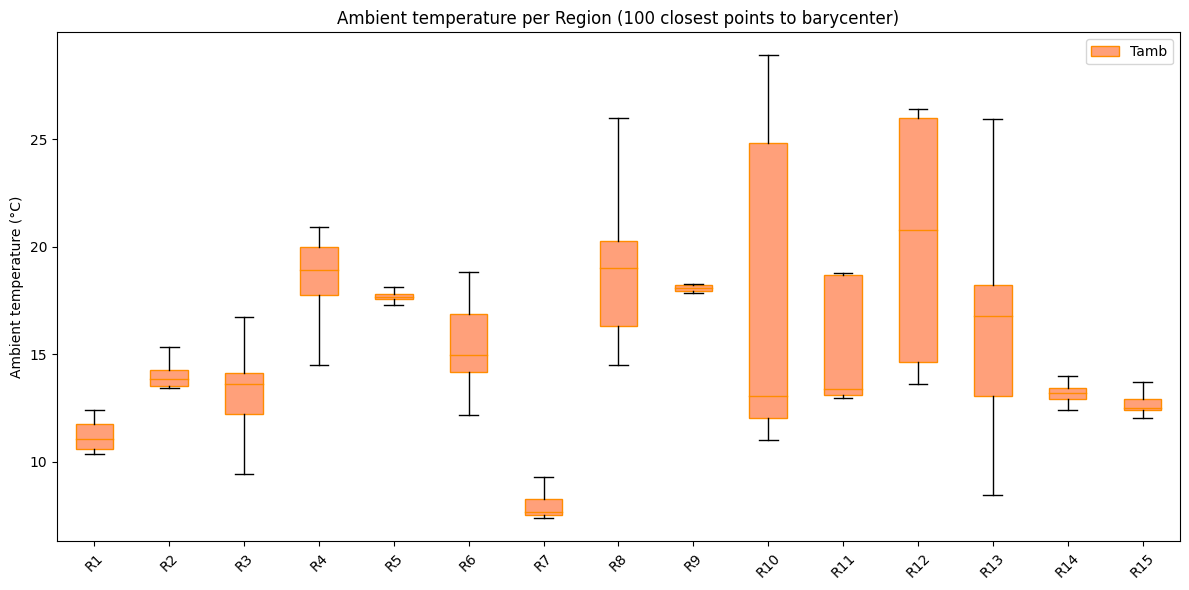

In [34]:
# 1) Detection of temperature columns
sample_df = next(iter(closest_per_region.values()))
temp_cols = [c for c in sample_df.columns if c.startswith("t") and c[1:].isdigit()]
print("Temperature columns :", temp_cols)

use_tamb = False
if not temp_cols:
    if "Tamb" in sample_df.columns:
        use_tamb = True
        print("No per-sensor temperature columns ('tXX') found. Falling back to ambient temperature ('Tamb').")
    else:
        raise ValueError("No temperature columns ('tXX' or 'Tamb') found in closest_per_region.")

region_ids = sorted(closest_per_region.keys())

if use_tamb:
    # --- Ambient temperature boxplot per region (single sensor, one box per region) ---
    tamb_data = []
    labels = []
    for rid in region_ids:
        df_r = closest_per_region[rid]
        if "Tamb" in df_r.columns:
            tamb_data.append(df_r["Tamb"].dropna().values)
        else:
            tamb_data.append([np.nan])
        labels.append(f"R{rid}")

    x = np.arange(len(region_ids))

    fig, ax = plt.subplots(figsize=(12, 6))
    bp_tamb = ax.boxplot(
        tamb_data,
        positions=x,
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor="lightsalmon", edgecolor="darkorange"),
        medianprops=dict(color="darkorange"),
        showfliers=False
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.set_ylabel("Ambient temperature (°C)")
    ax.set_title("Ambient temperature per Region (100 closest points to barycenter)")
    ax.legend([bp_tamb["boxes"][0]], ["Tamb"])

    plt.tight_layout()
    plt.show()

else:
    # 2) Find global min/max temperatures across all regions
    all_temp_vals = []

    for rid, df_r in closest_per_region.items():
        for c in temp_cols:
            if c in df_r.columns:
                vals = df_r[c].dropna().values
                if len(vals) > 0:
                    all_temp_vals.extend(vals)

    if not all_temp_vals:
        raise ValueError("No temperature values found in closest_per_region.")

    global_min = min(all_temp_vals)
    global_max = max(all_temp_vals)
    print("Global temp Y-limits:", global_min, global_max)

    # 3) Layout of subplots
    n_regions = len(region_ids)

    ncols = min(3, n_regions)
    nrows = int(np.ceil(n_regions / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(5*ncols, 4*nrows),
        squeeze=False
    )

    # 4) Plot per region
    for ax, rid in zip(axes.flatten(), region_ids):
        df_r = closest_per_region[rid]

        # extraire les données de température
        data = [df_r[c].dropna().values for c in temp_cols]

        ax.boxplot(
            data,
            showfliers=False,
            widths=0.5
        )

        ax.set_title(f"Region {rid} (n={len(df_r)})")
        ax.set_xticks(range(1, len(temp_cols) + 1))
        ax.set_xticklabels(temp_cols, rotation=90, fontsize=7)
        ax.set_ylabel("Temperature")

        # Same scale for y-axis
        ax.set_ylim(global_min, global_max)

    # Delete empty axes if needed
    for i in range(len(region_ids), nrows * ncols):
        fig.delaxes(axes.flatten()[i])

    plt.tight_layout()
    plt.show()

CO2 Plot

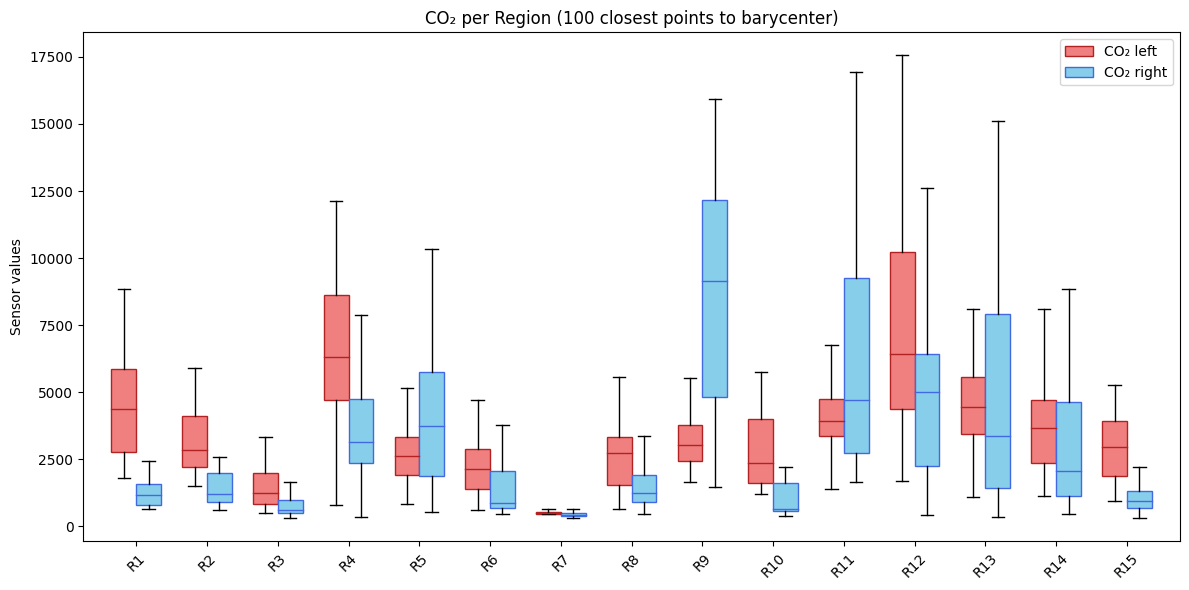

In [35]:
region_ids = sorted(closest_per_region.keys())
co2_data_right = []
co2_data_left = []
labels = []

for rid in region_ids:
    df_r = closest_per_region[rid]

    if "co2_R" in df_r.columns:
        co2_data_right.append(df_r["co2_R"].dropna().values)
    else:
        co2_data_right.append([np.nan])

    if "co2_L" in df_r.columns:
        co2_data_left.append(df_r["co2_L"].dropna().values)
    else:
        co2_data_left.append([np.nan])

    labels.append(f"R{rid}")

x = np.arange(len(region_ids))

fig, ax = plt.subplots(figsize=(12, 6))

w = 0.35
offset = w / 2.0

# boxplots CO2
bp_left = ax.boxplot(
    co2_data_left,
    positions=x - offset,
    widths=w,
    patch_artist=True,
    boxprops=dict(facecolor="lightcoral", edgecolor="firebrick"),
    medianprops=dict(color="firebrick"),
    showfliers=False
)
bp_right = ax.boxplot(
    co2_data_right,
    positions=x + offset,
    widths=w,
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", edgecolor="royalblue"),
    medianprops=dict(color="royalblue"),
    showfliers=False
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_xlim(-0.75, len(region_ids) - 0.25)
ax.set_ylabel("Sensor values")
ax.set_title("CO₂ per Region (100 closest points to barycenter)")

ax.legend([bp_left["boxes"][0], bp_right["boxes"][0]], ["CO₂ left", "CO₂ right"])

plt.tight_layout()
plt.show()

Humidity Plot

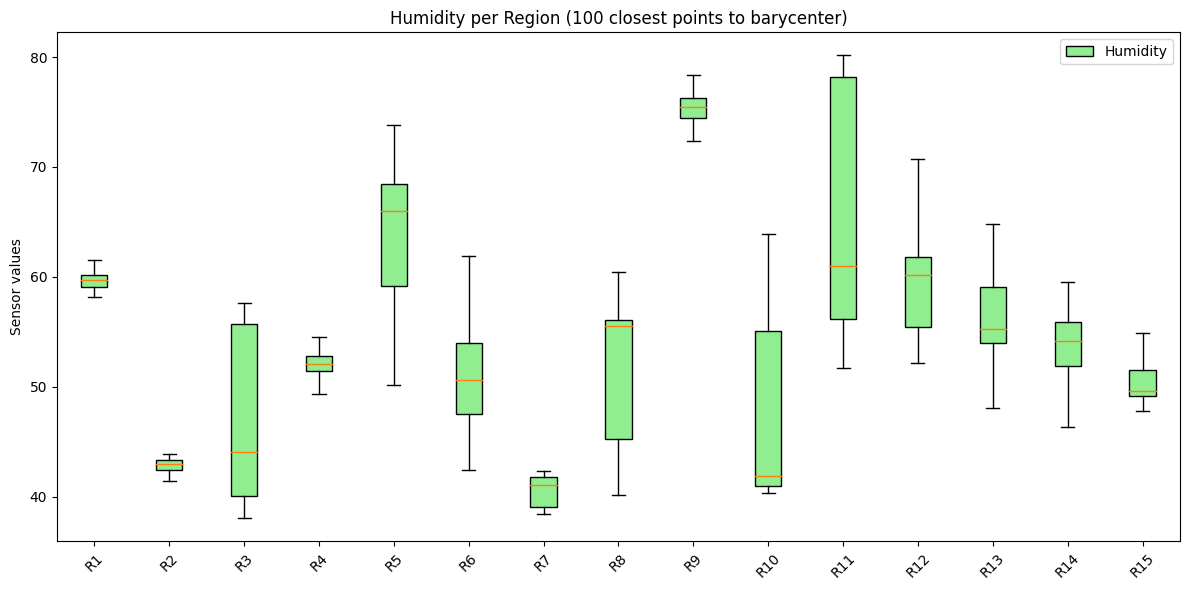

In [36]:
region_ids = sorted(closest_per_region.keys())

hum_data = []
labels = []

for rid in region_ids:
    df_r = closest_per_region[rid]

    if "rel_humid" in df_r.columns:
        hum_data.append(df_r["rel_humid"].dropna().values)
    else:
        hum_data.append([np.nan])
    
    labels.append(f"R{rid}")

x = np.arange(len(region_ids))

fig, ax = plt.subplots(figsize=(12, 6))

# boxplots Humidité
bp2 = ax.boxplot(
    hum_data,
    positions=x,
    widths=w,
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen"),
    showfliers=False
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel("Sensor values")
ax.set_title("Humidity per Region (100 closest points to barycenter)")

ax.legend([bp2["boxes"][0]], ["Humidity"])

plt.tight_layout()
plt.show()

Activity plots

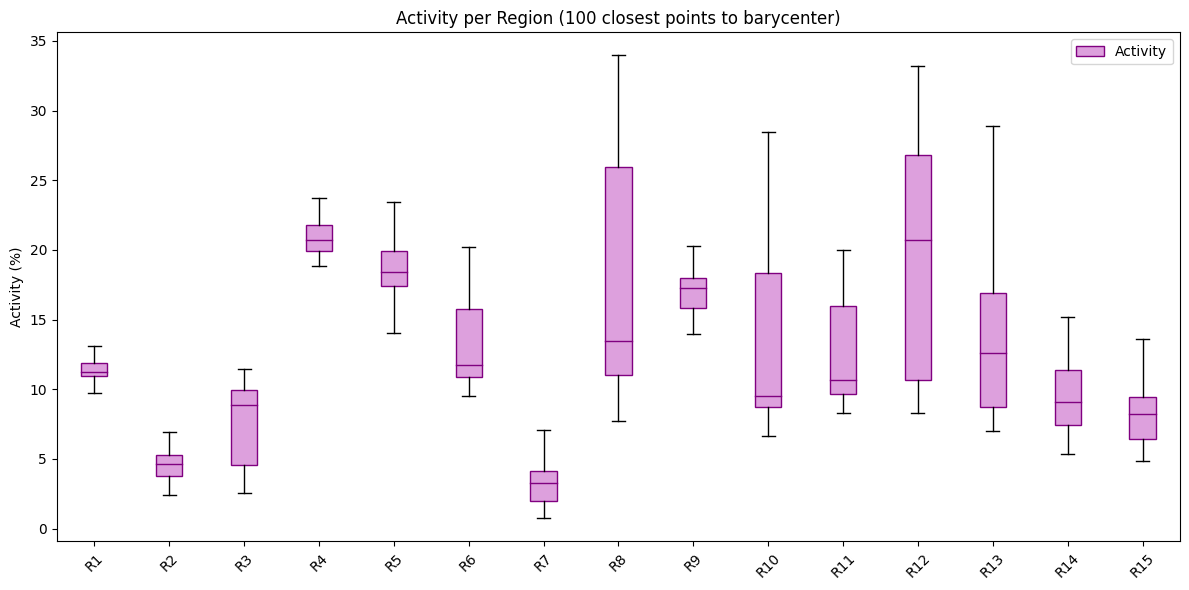

In [37]:
region_ids = sorted(closest_per_region.keys())

activity_data = []
labels = []

for rid in region_ids:
    df_r = closest_per_region[rid]
    if "activity" in df_r.columns:
        activity_data.append((df_r["activity"].dropna().values) * 100.0)  # convert to %
    else:
        activity_data.append([np.nan])
    labels.append(f"R{rid}")

x = np.arange(len(region_ids))

fig, ax = plt.subplots(figsize=(12, 6))

bp_act = ax.boxplot(
    activity_data,
    positions=x,
    widths=w if "w" in globals() else 0.35,
    patch_artist=True,
    boxprops=dict(facecolor="plum", edgecolor="purple"),
    medianprops=dict(color="purple"),
    showfliers=False
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel("Activity (%)")
ax.set_title("Activity per Region (100 closest points to barycenter)")
ax.legend([bp_act["boxes"][0]], ["Activity"])

plt.tight_layout()
plt.show()

Day/Night Count

Region 1: day=28, night=72, total=100
Region 2: day=31, night=69, total=100
Region 3: day=81, night=19, total=100
Region 4: day=63, night=37, total=100
Region 5: day=14, night=86, total=100
Region 6: day=57, night=43, total=100
Region 7: day=29, night=71, total=100
Region 8: day=53, night=47, total=100
Region 9: day=32, night=37, total=69
Region 10: day=57, night=43, total=100
Region 11: day=23, night=77, total=100
Region 12: day=37, night=63, total=100
Region 13: day=53, night=47, total=100
Region 14: day=33, night=67, total=100
Region 15: day=70, night=30, total=100


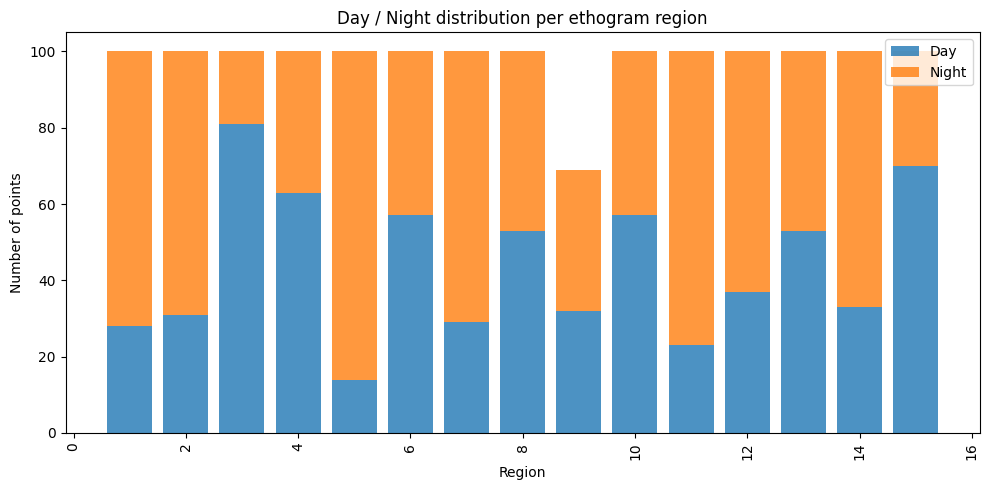

In [38]:
def is_day(ts):
    """Jour = 08:00 → 20:00 (inclus 8h, exclu 20h)"""
    hour = ts.hour
    return 8 <= hour < 20

day_night_counts = {}

for rid, df_r in closest_per_region.items():

    # --- Selest timestamp according to index type ---
    if isinstance(df_r.index, pd.MultiIndex):
        ts = df_r.index.get_level_values("timestamp")
    else:
        ts = df_r.index

    ts = pd.to_datetime(ts)

    # Series to allow .map()
    ts_series = pd.Series(ts)

    # day / night
    is_day_mask = ts_series.map(is_day).astype(bool)

    n_day = int(is_day_mask.sum())
    total = len(ts_series)
    n_night = int(total - n_day)

    day_night_counts[rid] = {
        "day": n_day,
        "night": n_night,
        "total": total
    }

# Print
for rid, c in day_night_counts.items():
    print(f"Region {rid}: day={c['day']}, night={c['night']}, total={c['total']}")
    
df_day_night = (
    pd.DataFrame.from_dict(day_night_counts, orient="index")
    .reset_index()
    .rename(columns={"index": "region"})
    .sort_values("region")
)

# Plot 

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    df_day_night["region"],
    df_day_night["day"],
    label="Day",
    alpha=0.8
)

ax.bar(
    df_day_night["region"],
    df_day_night["night"],
    bottom=df_day_night["day"],
    label="Night",
    alpha=0.8
)

ax.set_xlabel("Region")
ax.set_ylabel("Number of points")
ax.set_title("Day / Night distribution per ethogram region")

ax.legend()
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## Plot 10 points around barycentre

In [39]:
k = 10
rows = []

for region_id, bary in barycenters.items():
    df_r = df_nat[df_nat["region"] == region_id]
    if df_r.empty:
        continue

    coords = np.vstack(df_r["UMAP"].values).astype(float)
    dists = np.linalg.norm(coords - np.asarray(bary, dtype=float), axis=1)

    # index of the k nearest points
    k_eff = min(k, len(df_r))
    idx_topk = np.argsort(dists)[:k_eff]

    for rank, idx in enumerate(idx_topk, start=1):
        row = df_r.iloc[idx]

        real_ts = pd.to_datetime(row["real_timestamp"]) if "real_timestamp" in df_r.columns else pd.to_datetime(df_r.index[idx])
        source_id = row["source_id"] if "source_id" in df_r.columns else None

        row_dict = {
            "region": int(region_id),
            "rank": int(rank),                
            "distance": float(dists[idx]),
            "real_timestamp": real_ts,
            "source_id": source_id,
        }
        
        # copy all other useful columns (sensors, etc.), except UMAP and region
        for col in df_nat.columns:
            if col not in ["UMAP", "region"]:
                row_dict[col] = row[col]

        rows.append(row_dict)

df_region_top_ranks = (
    pd.DataFrame(rows)
    .set_index(["region", "rank"])
    .sort_index()
)


No per-sensor temperature columns ('tXX') found. Falling back to ambient temperature ('Tamb').


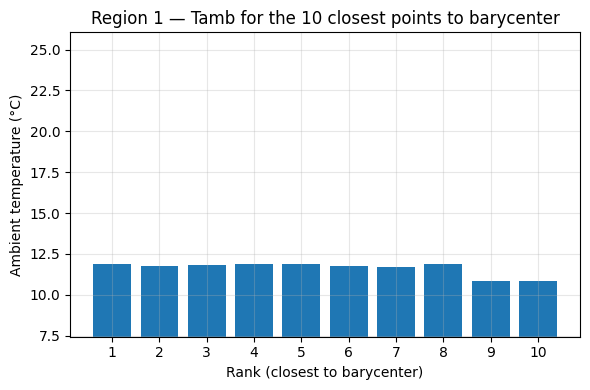

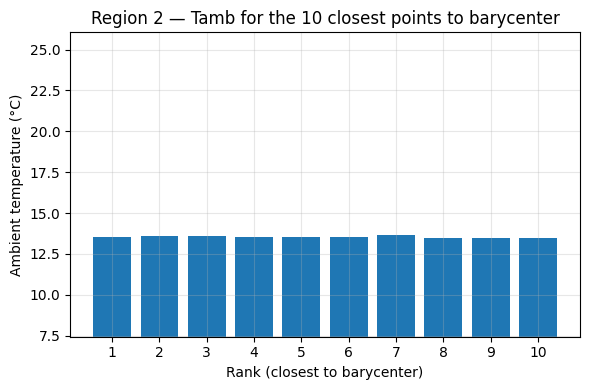

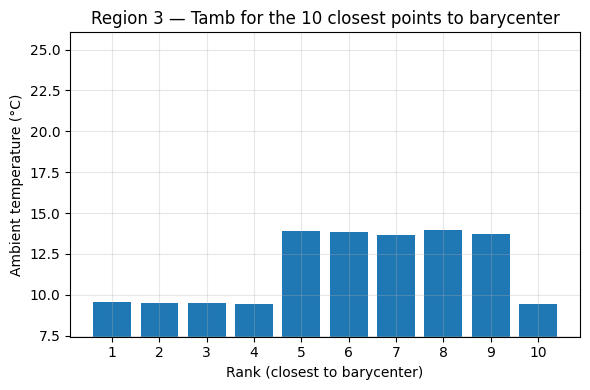

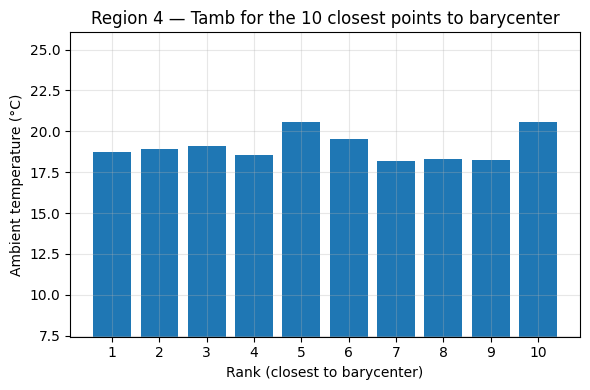

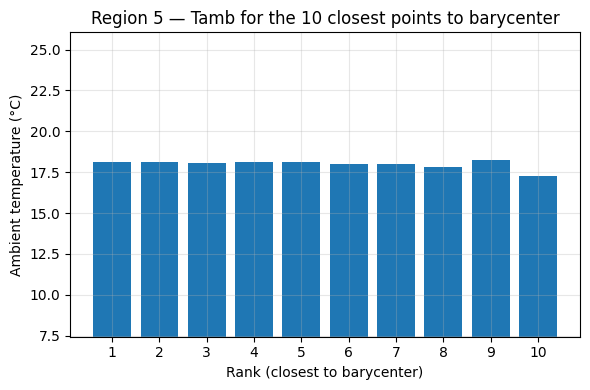

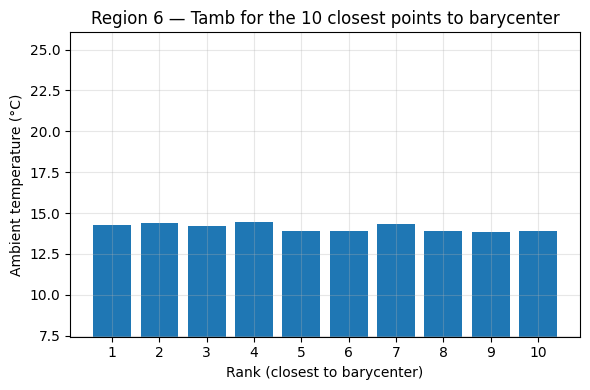

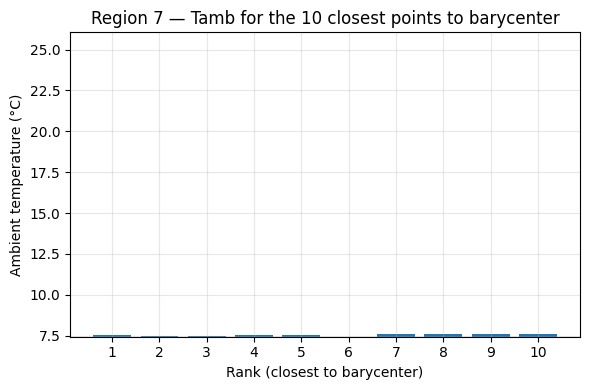

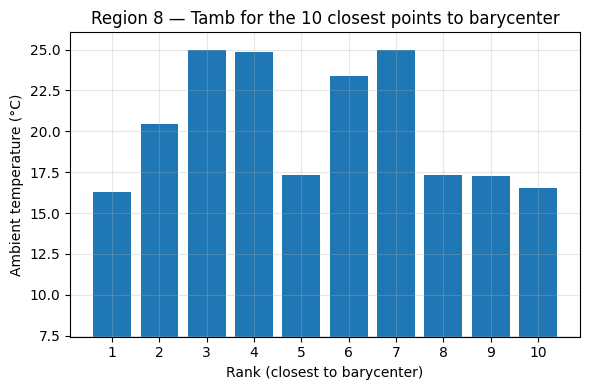

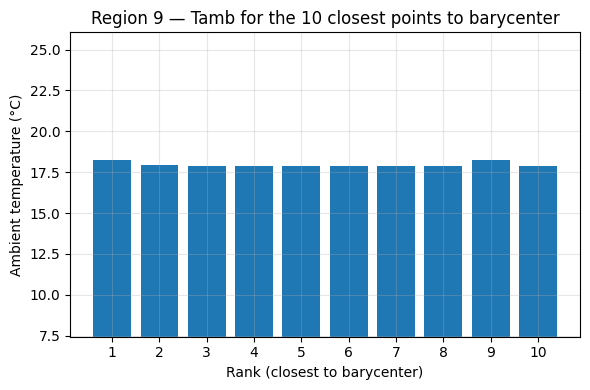

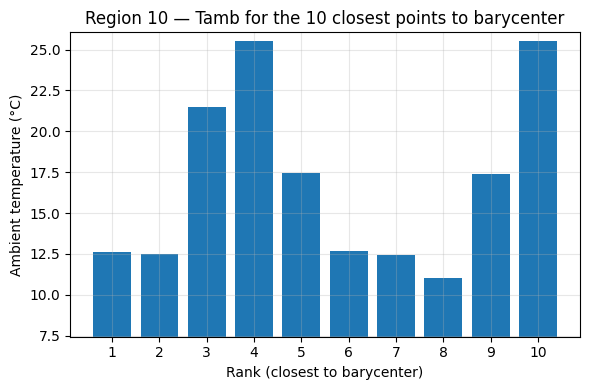

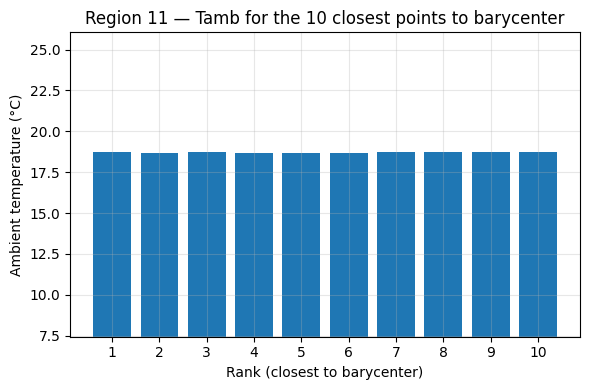

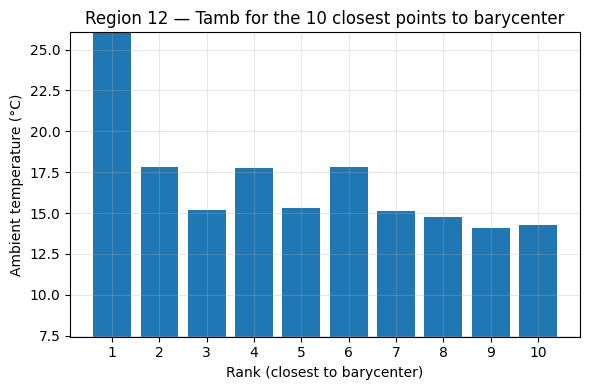

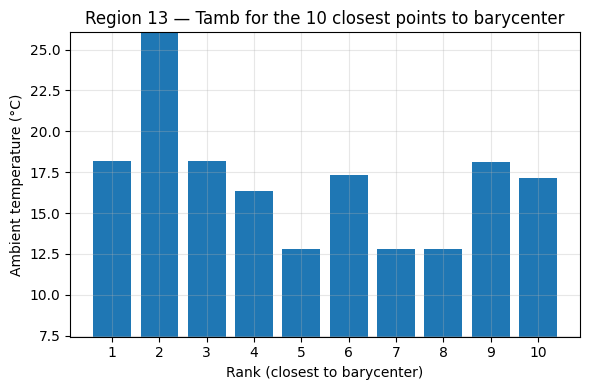

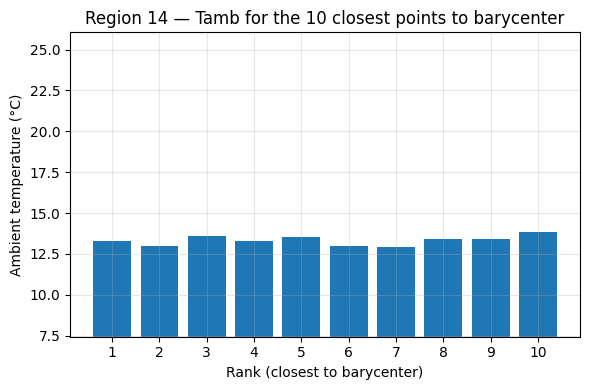

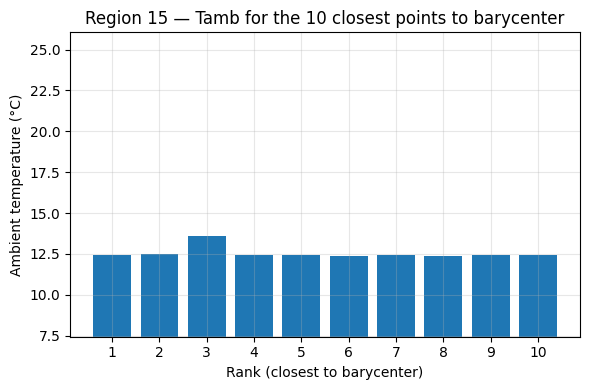

In [40]:
# temp columns
temp_cols = [c for c in df_nat.columns if c.startswith("t") and c[1:].isdigit()]
temp_cols = sorted(temp_cols)

# This Metabolism dataset only has ambient temperature ("Tamb"), not the 64-sensor "tXX"
# thermal grid the BlindVisualActivity dataset has -- without this fallback, temp_cols is
# empty, df_region_top_ranks[[]].min().min() silently evaluates to NaN, and plt.ylim(nan, nan)
# raises. Mirrors the same detection/fallback used for the 100-closest-points plot above.
use_tamb = False
if not temp_cols:
    if "Tamb" in df_nat.columns:
        use_tamb = True
        print("No per-sensor temperature columns ('tXX') found. Falling back to ambient temperature ('Tamb').")
    else:
        raise ValueError("No temperature columns ('tXX' or 'Tamb') found in df_nat.")

if use_tamb:
    # --- Ambient temperature per rank (single sensor, one point per closest-point rank) ---
    ymin = df_region_top_ranks["Tamb"].min()
    ymax = df_region_top_ranks["Tamb"].max()

    for region_id in df_region_top_ranks.index.get_level_values("region").unique():

        df_r10 = df_region_top_ranks.loc[region_id]   # index = rank (1..10)

        plt.figure(figsize=(6, 4))
        plt.bar(df_r10.index.astype(str), df_r10["Tamb"].astype(float))
        plt.ylim(ymin, ymax)

        plt.xlabel("Rank (closest to barycenter)")
        plt.ylabel("Ambient temperature (°C)")
        plt.title(f"Region {region_id} — Tamb for the 10 closest points to barycenter")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

else:
    # same scale
    ymin = df_region_top_ranks[temp_cols].min().min()
    ymax = df_region_top_ranks[temp_cols].max().max()

    x = np.arange(len(temp_cols))

    for region_id in df_region_top_ranks.index.get_level_values("region").unique():

        df_r10 = df_region_top_ranks.loc[region_id]   # index = rank (1..10)

        plt.figure(figsize=(10, 4))

        for rank, row in df_r10.iterrows():
            temps = row[temp_cols].values.astype(float)
            plt.plot(x, temps, marker='o', linewidth=1, label=f"rank {rank}")

        plt.xticks(x, temp_cols, rotation=90, fontsize=7)
        plt.ylim(ymin, ymax)

        plt.xlabel("Temperature sensors")
        plt.ylabel("Temperature (°C)")
        plt.title(f"Region {region_id} — 10 closest points to barycenter")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
